<a href="https://colab.research.google.com/github/Murcha1990/ML_AI24/blob/main/Hometasks/Pro/AI_HW6_uplift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

## Скачаем архив с данными по ссылке и разархивируем.

In [ ]:
!pip install gdown -q


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import gdown

url = 'https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO'
output = 'Data.zip'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO
From (redirected): https://drive.google.com/uc?id=19nKGaxm3RwHxh2UWPo537_-MDx21AkHO&confirm=t&uuid=812b2b77-a1c0-4fb9-a098-32b9402af9c3
To: c:\Users\admin\Desktop\ВШЭ\ML\ML_HSE\HW_6\Data.zip
100%|██████████| 289M/289M [00:32<00:00, 8.98MB/s] 


'Data.zip'

In [5]:
import zipfile

with zipfile.ZipFile('Data.zip', 'r') as zip_ref:
    zip_ref.extractall()

# <h2>Описание данных</h2>

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

# <h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [1]:
import pandas as pd

RANDOM_STATE=42

In [2]:
contracts = pd.read_csv('CONTRACTS_FINAL.csv')
contracts

,Unnamed: 0,user_id,contract_date,product_id,contract_id
0,39735,4008279,2024-11-03,1,0001_2024-11-03_4008279
1,44062,2079035,2024-11-08,1,0001_2024-11-08_2079035
2,9286,103088,2024-11-13,1,0001_2024-11-13_103088
3,45573,2026788,2024-11-02,1,0001_2024-11-02_2026788
4,150378,52269,2024-11-17,1,0001_2024-11-17_52269
...,...,...,...,...,...
286311,34316,1117397,2024-11-28,1,0001_2024-11-28_1117397
286312,101067,2071348,2024-11-12,1,0001_2024-11-12_2071348
286313,5389,4061197,2024-11-07,1,0001_2024-11-07_4061197
286314,33660,1139038,2024-11-02,1,0001_2024-11-02_1139038


In [3]:
contracts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286316 entries, 0 to 286315
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     286316 non-null  int64 
 1   user_id        286316 non-null  int64 
 2   contract_date  286316 non-null  object
 3   product_id     286316 non-null  int64 
 4   contract_id    286316 non-null  object
dtypes: int64(3), object(2)
memory usage: 10.9+ MB


In [4]:
#проверим корректность данных: количество уникальных продуктов (предполагается 1), и сроки заключения контрактов (предполагается ноябрь 2024)
print(contracts['product_id'].unique())

contracts['contract_date']=pd.to_datetime(contracts['contract_date'])
contracts[(contracts['contract_date'] >= pd.to_datetime('2024-11-30')) & (contracts['contract_date'] <= pd.to_datetime('2024-11-01'))]

[1]


,Unnamed: 0,user_id,contract_date,product_id,contract_id


In [5]:
campaings = pd.read_csv('CAMPAINGS.csv')
campaings

,Unnamed: 0,campaing_id,product_id,channel
0,0,iddqd,1,push
1,1,idclip,1,sms
2,2,iddt,1,banner
3,3,idkfa,1,other_ads


In [6]:
people_in_campaings = pd.read_csv('PEOPLE_IN_CAMPAINGS_FINAL.csv')
people_in_campaings

,Unnamed: 0,campaing_id,user_id,t_flag,delivery_date
0,29299,idclip,1099975,1,2024-11-06
1,36627,iddqd,1162,1,2024-11-08
2,134015,iddqd,42991,1,2024-11-07
3,57441,idclip,142343,0,unknown
4,48671,iddqd,24623,0,unknown
...,...,...,...,...,...
519995,107125,iddt,4108275,1,2024-11-04
519996,36366,iddqd,131927,1,2024-11-06
519997,98578,idclip,1074765,1,2024-11-05
519998,14272,iddqd,73995,0,unknown


In [7]:
people_in_campaings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520000 entries, 0 to 519999
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     520000 non-null  int64 
 1   campaing_id    520000 non-null  object
 2   user_id        520000 non-null  int64 
 3   t_flag         520000 non-null  int64 
 4   delivery_date  520000 non-null  object
dtypes: int64(3), object(2)
memory usage: 19.8+ MB


In [8]:
people_in_campaings.groupby('campaing_id').agg({'user_id' : 'count'})

,user_id
campaing_id,
idclip,120000
iddqd,160000
iddt,120000
idkfa,120000


In [9]:
#смерджим контракты с людьми по user_id, взяв из контрактов только дату заключения (покупки)
df= people_in_campaings.merge(contracts.drop(columns=['Unnamed: 0', 'product_id', 'contract_id']), on = 'user_id', how='left')
df

,Unnamed: 0,campaing_id,user_id,t_flag,delivery_date,contract_date
0,29299,idclip,1099975,1,2024-11-06,2024-11-11
1,36627,iddqd,1162,1,2024-11-08,2024-11-13
2,134015,iddqd,42991,1,2024-11-07,NaT
3,57441,idclip,142343,0,unknown,2024-11-17
4,48671,iddqd,24623,0,unknown,NaT
...,...,...,...,...,...,...
519995,107125,iddt,4108275,1,2024-11-04,2024-11-15
519996,36366,iddqd,131927,1,2024-11-06,2024-11-27
519997,98578,idclip,1074765,1,2024-11-05,NaT
519998,14272,iddqd,73995,0,unknown,NaT


In [10]:
#поменяем формат delivery_date на дату
df['delivery_date']=pd.to_datetime(df['delivery_date'], errors='coerce')

#добавим колонку с таргетом
df['target']=0
#теперь нужно разметить '1' клиентов, заключивших контракт в течение 2х недель после коммуникации
dates = pd.date_range(start="2024-01-01", periods=365, freq="D")
index_1=df[(df['t_flag']==1) & (df['contract_date'] >= df['delivery_date']) & (df['contract_date'] <= df['delivery_date'] + 14*dates.freq)].index
df.loc[index_1, 'target']=1
#проставим '1' клиентам без коммуникации, при наличии контракта, заключенного до 21 числа месяца
trashold = pd.to_datetime(str(df['contract_date'][0].year)+'-'+str(df['contract_date'][0].month)+'-21') #21 число месяца
index_1=df[(df['t_flag']==0) & (df['contract_date'] <= trashold)].index
df.loc[index_1, 'target']=1

#добавим технический столбец report_dt
df['report_dt']=pd.to_datetime('2024-09-30')

In [11]:
#по каждой кампании посмотрим структуру целевой и контрольной групп
df.groupby(['campaing_id', 'target', 't_flag']).agg({'user_id' : 'count'})

user_id
campaing_id target t_flag         
idclip      0      0         18905
                   1         47930
            1      0         41095
                   1         12070
iddqd       0      0         63828
                   1         31861
            1      0         16172
                   1         48139
iddt        0      0         35956
                   1         23837
            1      0         24044
                   1         36163
idkfa       0      0         35956
                   1         23837
            1      0         24044
                   1         36163

In [12]:
df.groupby(['campaing_id', 'target']).agg({'user_id' : 'count'})

user_id
campaing_id target         
idclip      0         66835
            1         53165
iddqd       0         95689
            1         64311
iddt        0         59793
            1         60207
idkfa       0         59793
            1         60207

In [13]:
print(f"В выборке {df.shape[0]} наблюдений, но уникальных юзеров {df['user_id'].nunique()}. Значит {df.shape[0] - df['user_id'].nunique()} юзеров участвовали более чем в одной кампаниии")

В выборке 520000 наблюдений, но уникальных юзеров 460000. Значит 60000 юзеров участвовали более чем в одной кампаниии


### ваши выводы здесь


* в кампании idclip (смс) без комуникации количество покупок в 4 раза выше, чем с коммуникацией. В остальных кампаниях количество покупок с флагом коммуникации больше, чем без коммуникации. 

* 60 тыс юзеров участвовали более чем в одной кампании, значит будет сложно понять, в результате какого именно взаимодействия совершено целевое действие.

# <h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

In [14]:
# ваш код здесь
aggs=pd.read_csv('AGGS_FINAL.csv')
aggs

,Unnamed: 0,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt,user_id,age,city
0,104548,0.654343,-1.439286,-0.011475,2.039457,0.843580,-0.977480,-0.768019,-1.044127,0.025673,2025-01-31,1066338,26,Ufa
1,38396,2.583579,1.755569,3.360186,-1.122864,0.034201,-0.269607,-1.503646,1.040289,-1.691606,2024-11-30,13900,35,Ufa
2,227077,0.296030,-0.937075,1.073280,1.874636,-0.981216,-1.100187,-0.331181,-1.575637,0.474965,2025-03-31,4063636,28,Ufa
3,304649,2.329328,-1.345159,0.345066,0.755373,-0.082842,0.028439,0.919211,0.808793,-0.560004,2025-03-31,1025488,27,Moscow
4,239518,0.167643,1.587099,0.165357,0.289758,-1.108840,-1.501819,0.615588,1.631203,-0.208419,2025-02-28,4040555,37,Moscow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2759995,100191,0.311284,-0.232406,-0.208223,1.006051,-1.498279,0.306518,1.135627,1.169791,-0.106392,2025-02-28,61957,38,Ufa
2759996,342943,-1.970020,1.180142,-0.572525,1.052022,-0.654687,0.744590,-2.342623,-0.136155,0.582400,2025-01-31,132172,40,Moscow
2759997,186830,0.403995,-0.350153,-0.584462,0.123843,-1.015746,0.922963,1.549083,1.210031,-0.706992,2025-03-31,4028256,34,Smolensk
2759998,76230,2.218275,-0.344427,1.281239,3.781907,3.658907,1.282129,0.324350,0.982721,2.046261,2025-02-28,1097844,40,Smolensk


In [15]:
aggs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2760000 entries, 0 to 2759999
Data columns (total 14 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Unnamed: 0  int64  
 1   x1          float64
 2   x2          float64
 3   x3          float64
 4   x4          float64
 5   x5          float64
 6   x6          float64
 7   x7          float64
 8   x8          float64
 9   x9          float64
 10  report_dt   object 
 11  user_id     int64  
 12  age         int64  
 13  city        object 
dtypes: float64(9), int64(3), object(2)
memory usage: 294.8+ MB


In [16]:
#столбец report_dt по которому нам требуется провести фильтрацию имеет формат object, но мы хотим работать с ним как с датой, поэтому следует поменять формат
aggs['report_dt']=pd.to_datetime(aggs['report_dt'])

#теперь можно оставить только данные за сентябрь 2024 
sept_aggs = aggs[( aggs['report_dt'] >= pd.to_datetime('2024-09-01') ) & ( aggs['report_dt'] <= pd.to_datetime('2024-09-30') )]
#и добавить их к датасету из п.1
data = df.merge(sept_aggs, on ='user_id', how='left')
data.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y', 'report_dt_y'], inplace=True)
data

,campaing_id,user_id,t_flag,delivery_date,contract_date,target,report_dt_x,x1,x2,x3,x4,x5,x6,x7,x8,x9,age,city
0,idclip,1099975,1,2024-11-06,2024-11-11,1,2024-09-30,0.822461,1.233201,-1.000185,2.585873,-0.584520,-0.268274,-0.727814,1.606372,1.814158,42,Moscow
1,iddqd,1162,1,2024-11-08,2024-11-13,1,2024-09-30,-1.224545,1.688111,0.150933,3.230149,-0.189105,0.551481,-1.229590,1.159411,-0.085720,39,Moscow
2,iddqd,42991,1,2024-11-07,NaT,0,2024-09-30,-0.916137,1.368764,1.841319,-1.529691,-0.608003,-1.116932,1.178124,-0.884607,-1.726070,43,Moscow
3,idclip,142343,0,NaT,2024-11-17,1,2024-09-30,-1.620401,2.449667,1.131850,1.021660,-1.212641,0.958422,1.039261,-0.964264,-2.225545,39,Smolensk
4,iddqd,24623,0,NaT,NaT,0,2024-09-30,2.281651,-0.354332,1.288191,-2.754188,0.202581,0.831745,-0.002779,-1.463527,1.976755,39,Ufa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519995,iddt,4108275,1,2024-11-04,2024-11-15,1,2024-09-30,0.527103,-0.466468,2.738080,1.613084,-1.171931,0.311911,-0.932750,-0.751979,-0.503718,36,Ufa
519996,iddqd,131927,1,2024-11-06,2024-11-27,0,2024-09-30,2.521111,-1.893176,2.540412,-1.912528,1.392247,-0.653322,0.541760,-1.209625,1.752634,42,Ufa
519997,idclip,1074765,1,2024-11-05,NaT,0,2024-09-30,0.880339,-0.423661,1.349334,-1.435748,3.511723,1.146370,-0.202532,-0.509698,-0.871800,28,Moscow
519998,iddqd,73995,0,NaT,NaT,0,2024-09-30,0.665340,1.771079,-0.323533,-1.224266,0.252920,-0.745952,-0.472200,0.879810,0.949838,29,Smolensk


## Импорты библиотек для визуализации, функция psi, функция для EDA

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import TargetEncoder

import numpy as np

def calculate_psi(expected, actual, buckettype='bins', buckets=10, axis=0):
    '''Calculate the PSI (population stability index) across all variables

    Args:
       expected: numpy matrix of original values
       actual: numpy matrix of new values
       buckettype: type of strategy for creating buckets, bins splits into even splits, quantiles splits into quantile buckets
       buckets: number of quantiles to use in bucketing variables
       axis: axis by which variables are defined, 0 for vertical, 1 for horizontal

    Returns:
       psi_values: ndarray of psi values for each variable

    Author:
       Matthew Burke
       github.com/mwburke
       mwburke.github.io.com
    '''

    def psi(expected_array, actual_array, buckets):
        '''Calculate the PSI for a single variable

        Args:
           expected_array: numpy array of original values
           actual_array: numpy array of new values, same size as expected
           buckets: number of percentile ranges to bucket the values into

        Returns:
           psi_value: calculated PSI value
        '''

        def scale_range (input, min, max):
            input += -(np.min(input))
            input /= np.max(input) / (max - min)
            input += min
            return input

        breakpoints = np.arange(0, buckets + 1) / (buckets) * 100

        if buckettype == 'bins':
            breakpoints = scale_range(breakpoints, np.min(expected_array), np.max(expected_array))
        elif buckettype == 'quantiles':
            breakpoints = np.stack([np.percentile(expected_array, b) for b in breakpoints])

        expected_fractions = np.histogram(expected_array, breakpoints)[0] / len(expected_array)
        actual_fractions = np.histogram(actual_array, breakpoints)[0] / len(actual_array)

        def sub_psi(e_perc, a_perc):
            '''Calculate the actual PSI value from comparing the values.
               Update the actual value to a very small number if equal to zero
            '''
            if a_perc == 0:
                a_perc = 0.0001
            if e_perc == 0:
                e_perc = 0.0001

            value = (e_perc - a_perc) * np.log(e_perc / a_perc)
            return(value)

        psi_value = sum(sub_psi(expected_fractions[i], actual_fractions[i]) for i in range(0, len(expected_fractions)))

        return(psi_value)

    if len(expected.shape) == 1:
        psi_values = np.empty(len(expected.shape))
    else:
        psi_values = np.empty(expected.shape[1 - axis])

    for i in range(0, len(psi_values)):
        if len(psi_values) == 1:
            psi_values = psi(expected, actual, buckets)
        elif axis == 0:
            psi_values[i] = psi(expected[:,i], actual[:,i], buckets)
        elif axis == 1:
            psi_values[i] = psi(expected[i,:], actual[i,:], buckets)

    return(psi_values)

In [18]:
def campaing_EDA(name: str):
    ''' 
    Функция для анализа данных по кампании

    :name - название кампании
    '''
    #выбор данных соответствующей кампании
    camp_df = data[data['campaing_id']==name]
    camp_df=camp_df.drop(columns=['user_id'])
    #расчет среднего
    print(f'Выборочное среднее по целевой и контрольной группе, кампания {name}')
    print (camp_df.select_dtypes(include=['int', 'float']).groupby(by='t_flag').mean())
    print()
    #расчет медианы
    print('Медиана по целевой и контрольной группе, кампания {name}')
    print (camp_df.select_dtypes(include=['int', 'float']).groupby(by='t_flag').median())
    print()
    #плотности распределений целевой и контрольной группы по признакам
    for col in camp_df.select_dtypes(include=['int', 'float']).columns.to_list()[2:]:
        sns.histplot(data = camp_df, x=col, hue='t_flag').set_title(col)
        plt.show()
    #расчет индекса psi
    df_1 = camp_df.drop(columns = ['target'])
    df_1.t_flag = df_1.t_flag.astype('str')
    df_1.t_flag = df_1.t_flag.replace({'0':'control',
                                        '1':'test'})
    df_1 = df_1.rename(columns={'t_flag':'group'})

    for col in df_1.select_dtypes(include=['int', 'float']):
        psi = calculate_psi(expected = df_1[df_1.group == 'control'][col],
                            actual = df_1[df_1.group == 'test'][col])
        print(f'psi для признака {col} равно {psi:.4f}')
    return camp_df
    

## EDA idclip

Выборочное среднее по целевой и контрольной группе, кампания idclip
          target        x1        x2        x3        x4        x5        x6  \
t_flag                                                                         
0       0.684917  0.612525  1.002071  0.996160 -0.605374  0.609060 -0.002922   
1       0.201167  0.613410  1.001479  0.996336 -0.606077  0.607142 -0.003577   

              x7        x8        x9      age  
t_flag                                         
0      -0.002243 -0.003985  0.531859  32.4595  
1      -0.003194 -0.002058  0.532910  32.5388  

Медиана по целевой и контрольной группе, кампания {name}
        target        x1        x2        x3        x4        x5        x6  \
t_flag                                                                       
0          1.0  0.695846  1.001579  0.995263 -0.692065  0.731157 -0.004754   
1          0.0  0.688788  0.996818  0.998904 -0.689447  0.724927 -0.008930   

              x7        x8        x9   age  
t_f

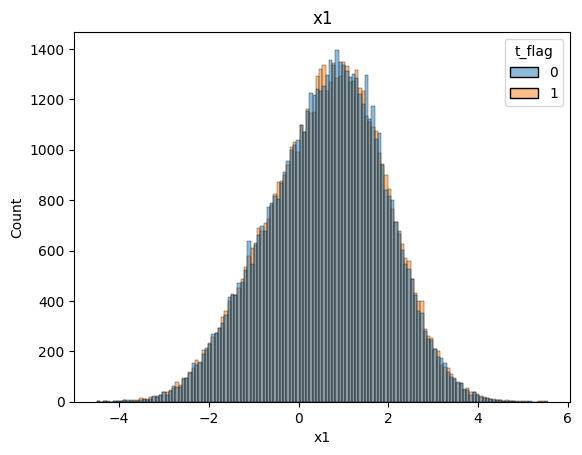

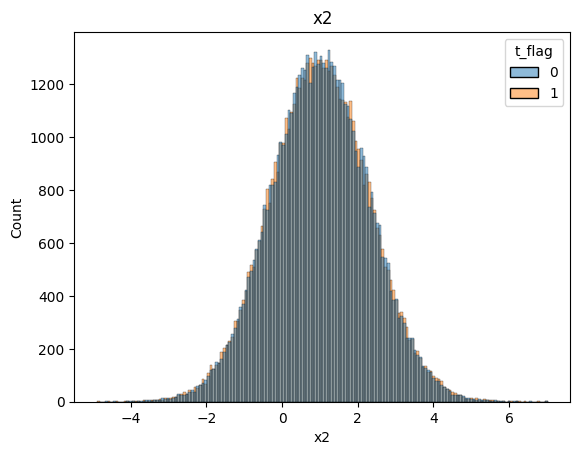

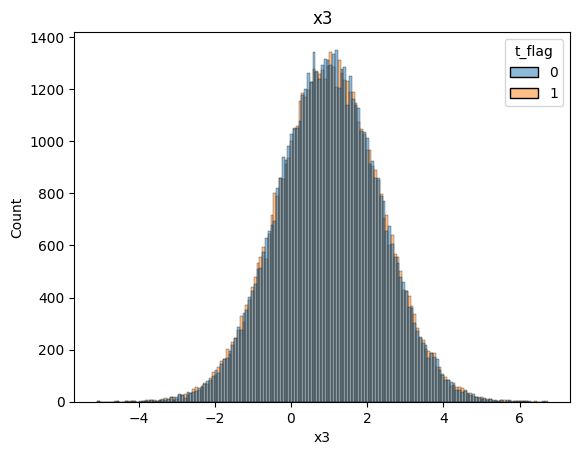

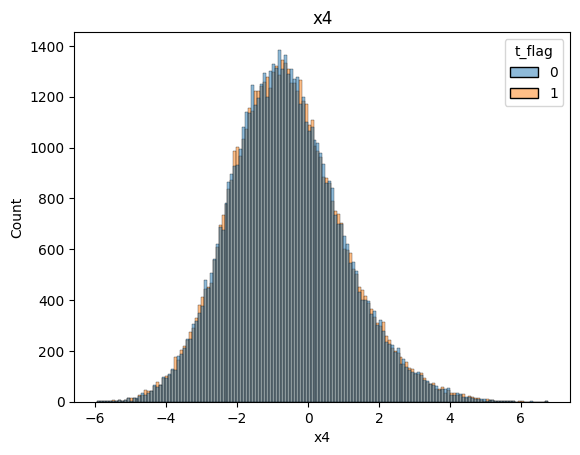

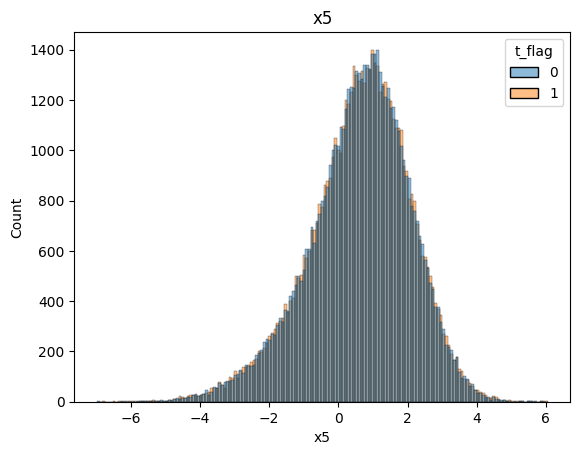

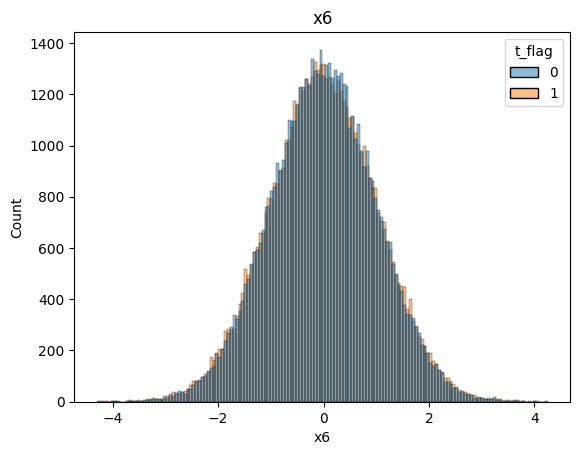

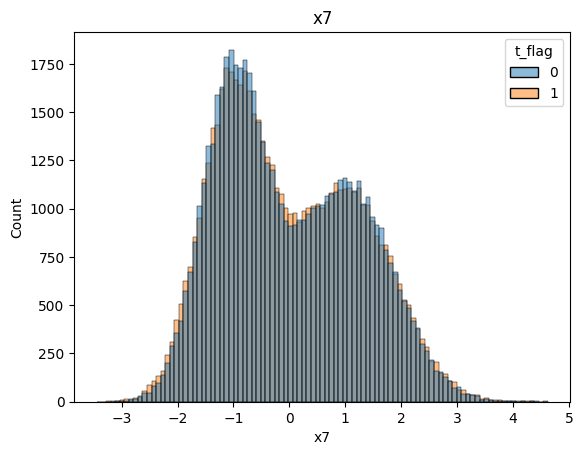

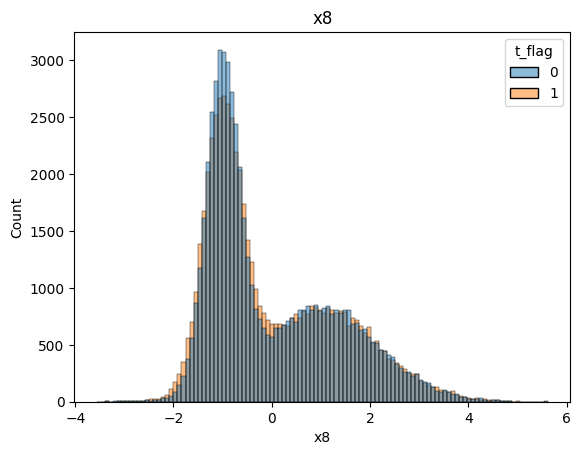

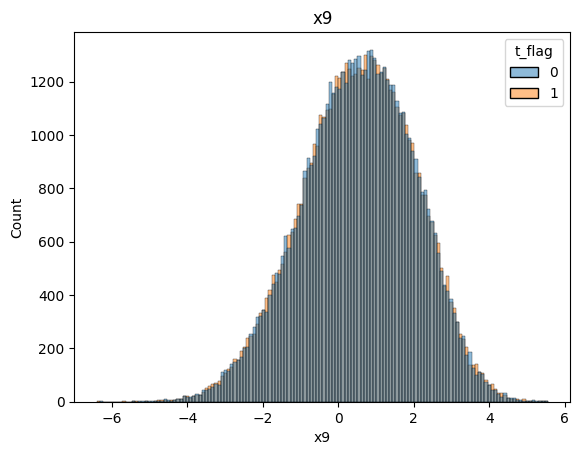

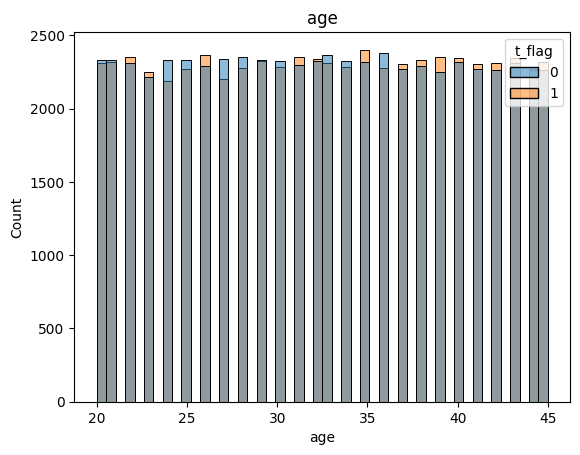

psi для признака x1 равно 0.0004
psi для признака x2 равно 0.0003
psi для признака x3 равно 0.0005
psi для признака x4 равно 0.0001
psi для признака x5 равно 0.0002
psi для признака x6 равно 0.0011
psi для признака x7 равно 0.0020
psi для признака x8 равно 0.0097
psi для признака x9 равно 0.0002
psi для признака age равно 0.0003


In [19]:
idclip_df = campaing_EDA('idclip')

**ВЫВОД**

* выборочные средние и медианы сопоставимы для целевой и контрольной групп

* согласно графикам и psi выборки статистически идентичны

## EDA iddqd

Выборочное среднее по целевой и контрольной группе, кампания iddqd
          target        x1        x2        x3        x4        x5        x6  \
t_flag                                                                         
0       0.202150  0.604476  0.991262  0.989826 -0.606210  0.592924 -0.002248   
1       0.601738  0.601202  1.004994  0.996935 -0.596487  0.601505 -0.002147   

              x7        x8        x9        age  
t_flag                                           
0      -0.002248 -0.000358  0.524898  32.504013  
1      -0.004232 -0.003318  0.523636  32.448462  

Медиана по целевой и контрольной группе, кампания {name}
        target        x1        x2        x3        x4        x5        x6  \
t_flag                                                                       
0          0.0  0.690167  0.991941  0.991280 -0.698398  0.715804  0.000645   
1          1.0  0.684945  1.003702  0.994629 -0.683922  0.723315 -0.003707   

              x7        x8        x9   ag

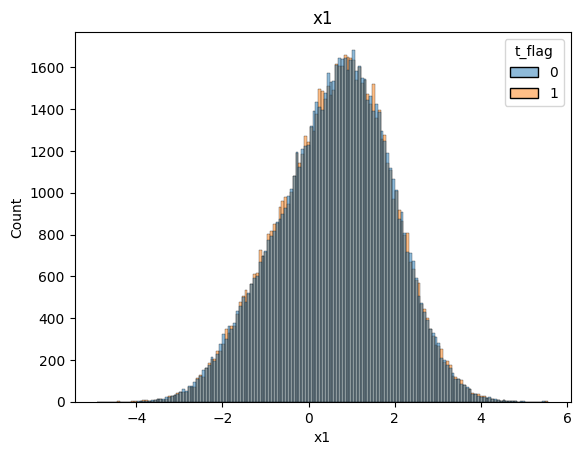

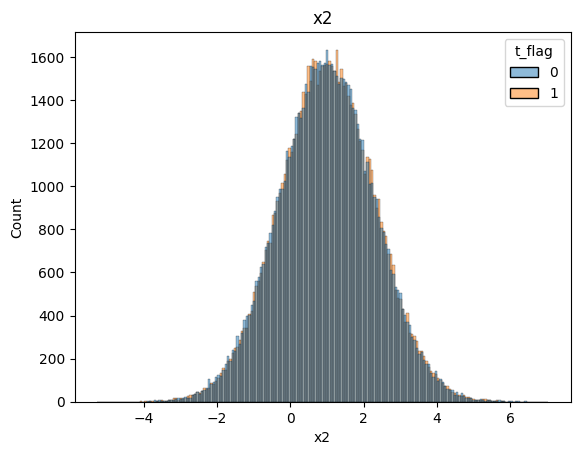

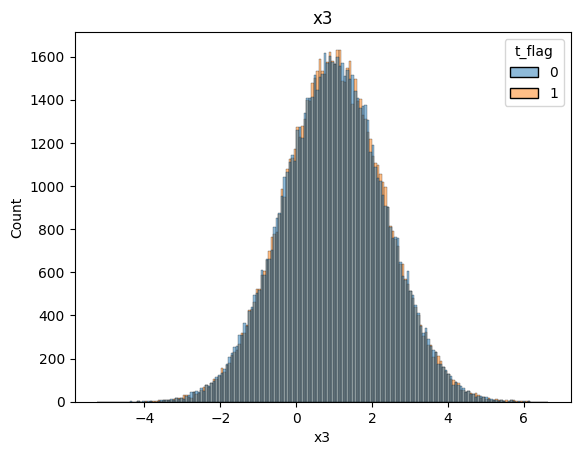

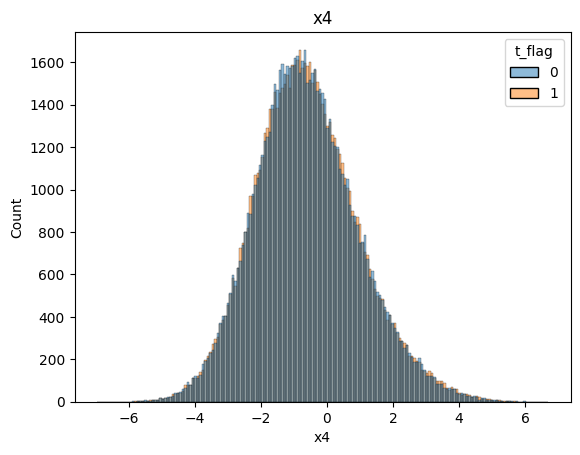

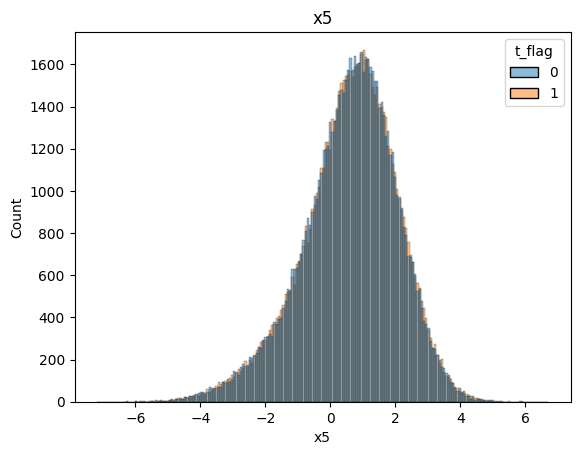

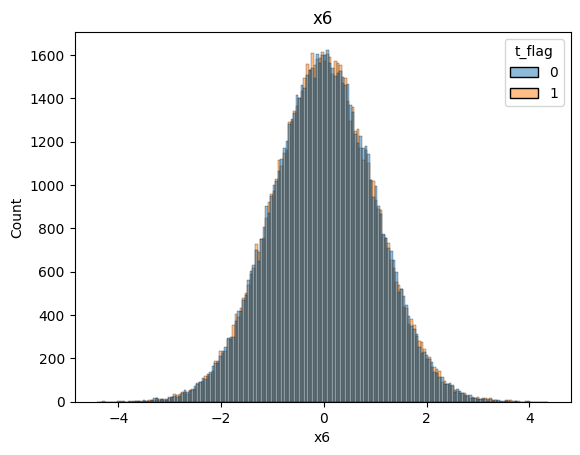

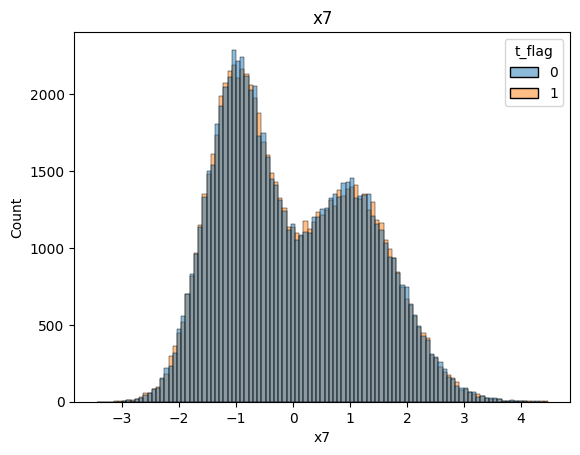

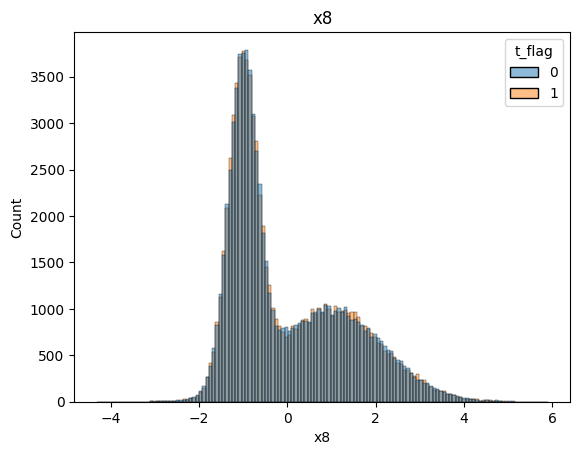

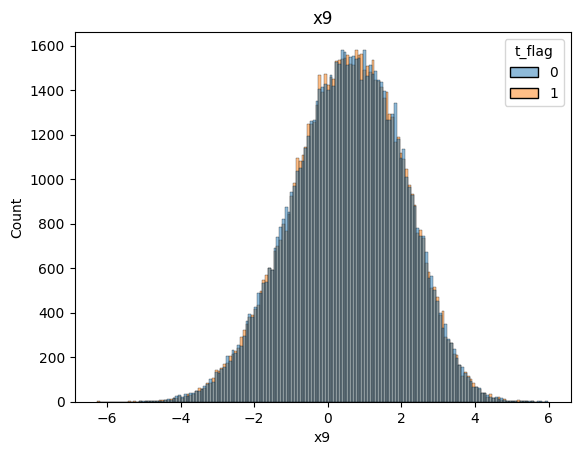

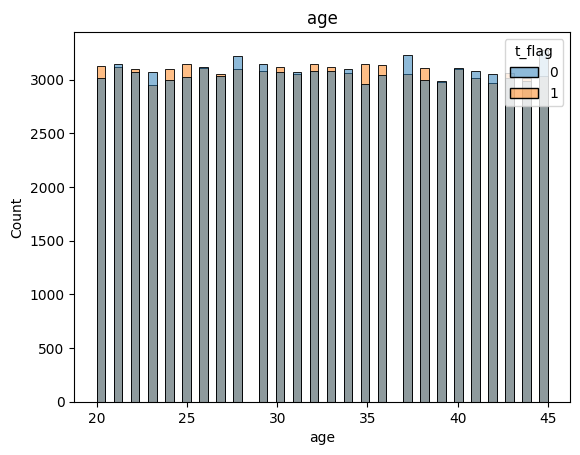

psi для признака x1 равно 0.0003
psi для признака x2 равно 0.0002
psi для признака x3 равно 0.0002
psi для признака x4 равно 0.0003
psi для признака x5 равно 0.0002
psi для признака x6 равно 0.0002
psi для признака x7 равно 0.0002
psi для признака x8 равно 0.0003
psi для признака x9 равно 0.0001
psi для признака age равно 0.0002


In [82]:
iddqd_df = campaing_EDA('iddqd')

**ВЫВОД**

* выборочные средние и медианы сопоставимы для целевой и контрольной групп

* согласно графикам и psi выборки статистически идентичны

## EDA iddt

Выборочное среднее по целевой и контрольной группе, кампания iddt
          target        x1        x2        x3        x4        x5        x6  \
t_flag                                                                         
0       0.400733 -0.200788 -1.005438  0.195224 -0.201540  0.005851 -0.000878   
1       0.602717 -0.190153 -0.996064  0.201646 -0.199495 -0.003222  0.002184   

              x7        x8        x9        age  
t_flag                                           
0       0.335597  0.333879 -0.231895  32.531317  
1       0.335707  0.332511 -0.234196  32.500350  

Медиана по целевой и контрольной группе, кампания {name}
        target        x1        x2       x3        x4        x5        x6  \
t_flag                                                                      
0          0.0 -0.039344 -1.000710  0.15114 -0.191527  0.004826  0.001446   
1          1.0 -0.029260 -0.992088  0.16389 -0.182136 -0.004370  0.006098   

              x7        x8        x9   age  
t

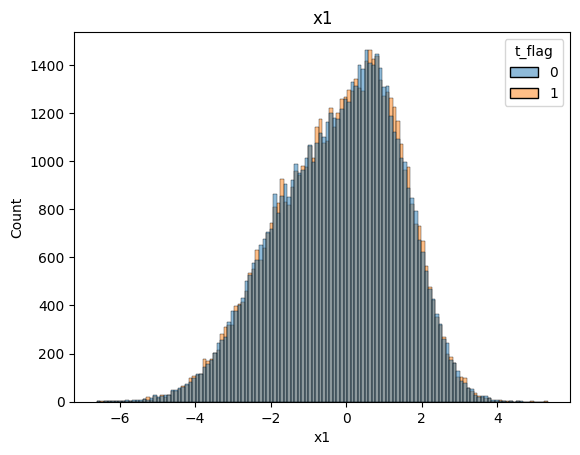

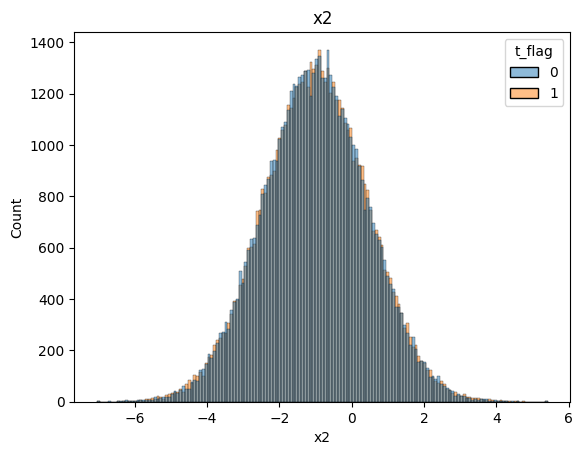

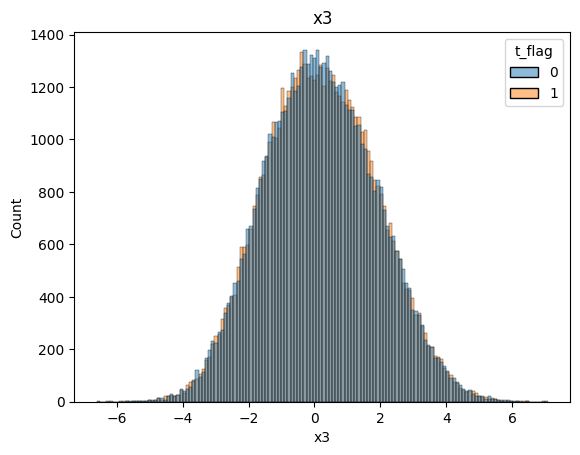

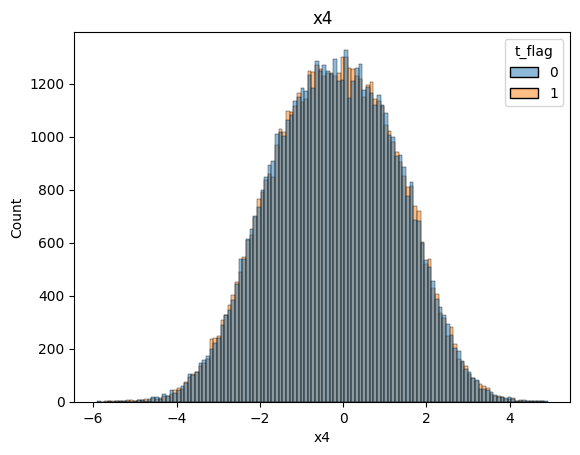

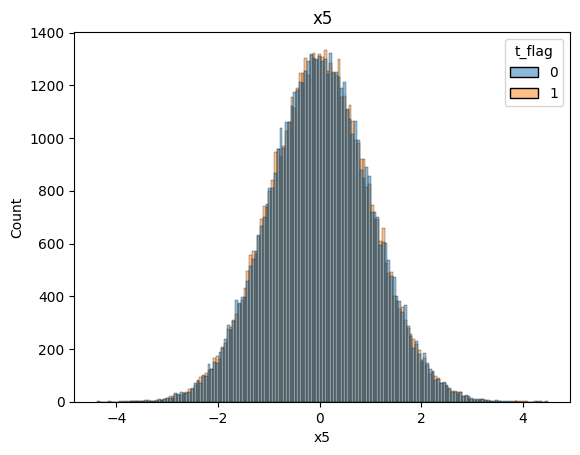

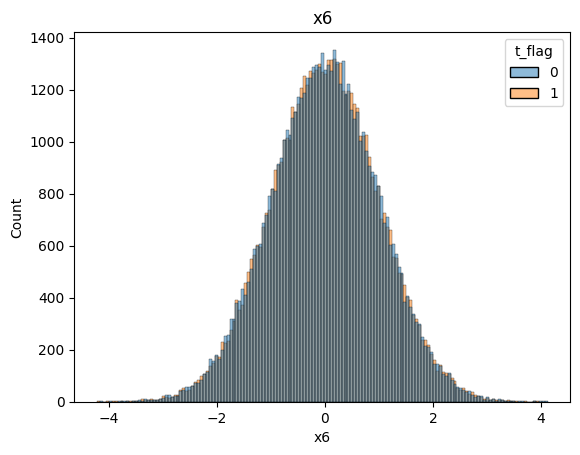

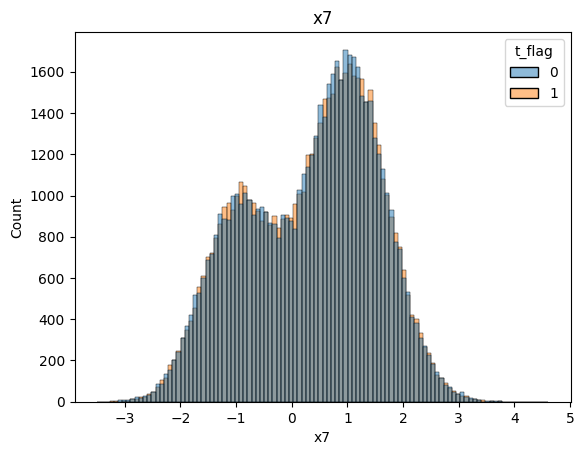

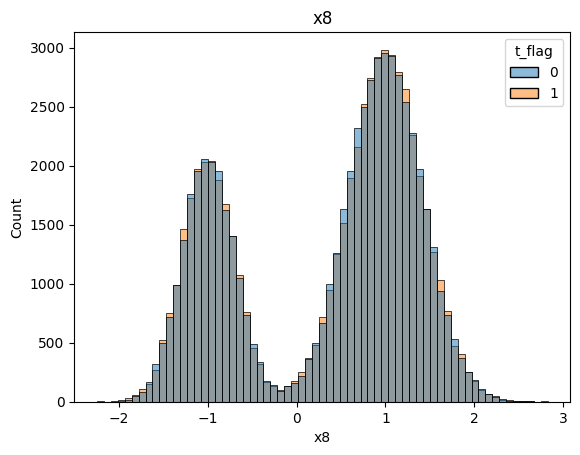

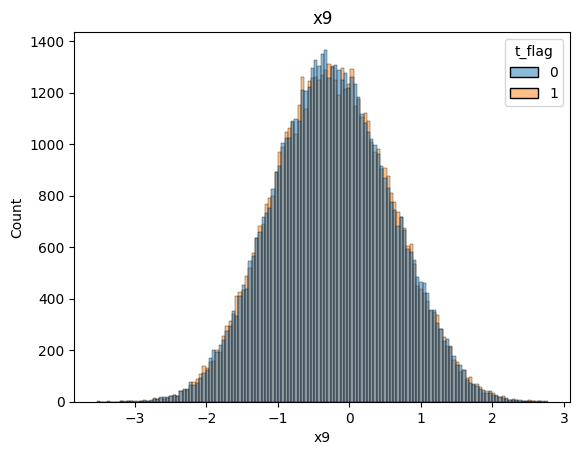

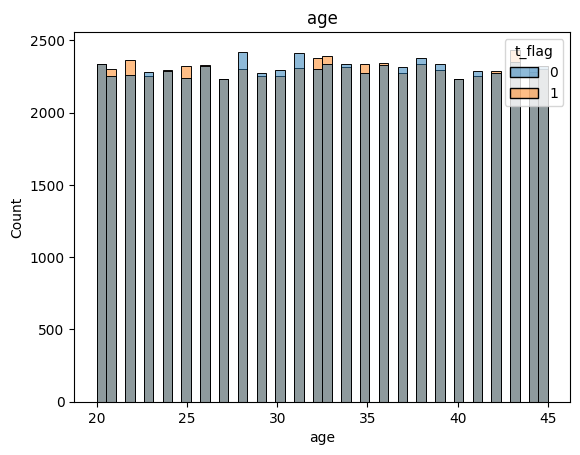

psi для признака x1 равно 0.0004
psi для признака x2 равно 0.0003
psi для признака x3 равно 0.0002
psi для признака x4 равно 0.0001
psi для признака x5 равно 0.0002
psi для признака x6 равно 0.0002
psi для признака x7 равно 0.0004
psi для признака x8 равно 0.0004
psi для признака x9 равно 0.0004
psi для признака age равно 0.0002


In [21]:
iddt_df = campaing_EDA('iddt')

**ВЫВОД**

* выборочные средние и медианы сопоставимы для целевой и контрольной групп

* согласно графикам и psi выборки статистически идентичны

## EDA idkfa

Выборочное среднее по целевой и контрольной группе, кампания idkfa
          target        x1        x2        x3        x4        x5        x6  \
t_flag                                                                         
0       0.400733 -0.200788 -1.005438  0.195224 -0.201540  0.000000 -0.000878   
1       0.602717 -0.190153 -0.996064  0.201646 -0.199495 -0.003222  0.002184   

              x7        x8        x9       age  
t_flag                                          
0       0.335597  0.333879 -0.231895  32.56505  
1       0.335707  0.332511 -0.234196  32.49420  

Медиана по целевой и контрольной группе, кампания {name}
        target        x1        x2       x3        x4       x5        x6  \
t_flag                                                                     
0          0.0 -0.039344 -1.000710  0.15114 -0.191527  0.00000  0.001446   
1          1.0 -0.029260 -0.992088  0.16389 -0.182136 -0.00437  0.006098   

              x7        x8        x9   age  
t_flag  

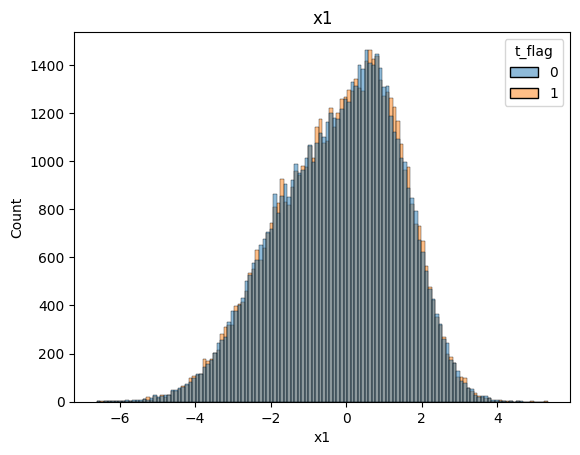

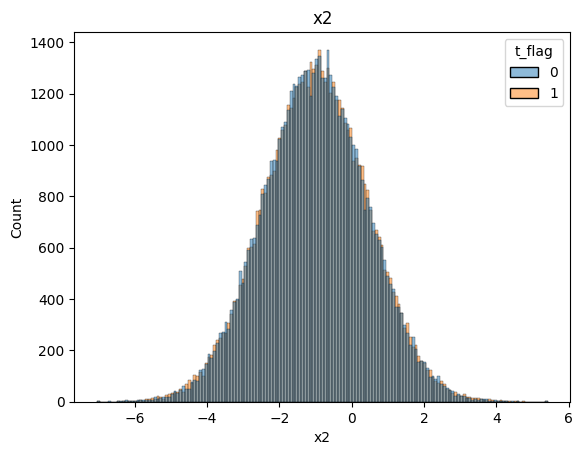

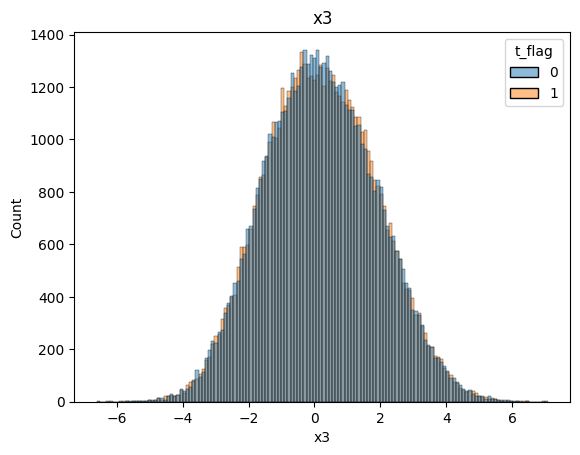

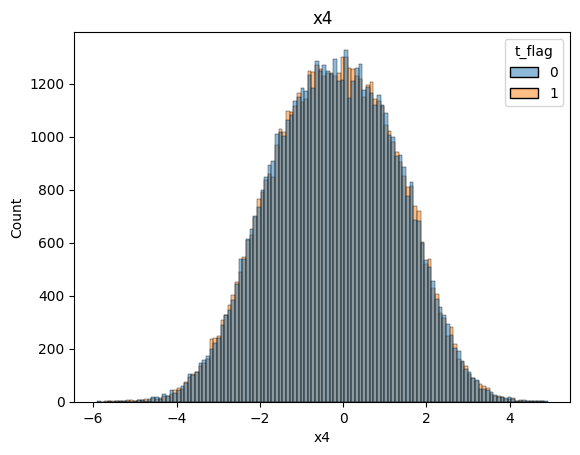

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


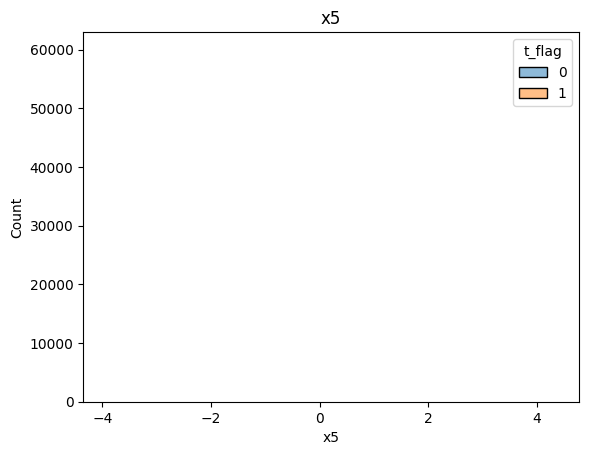

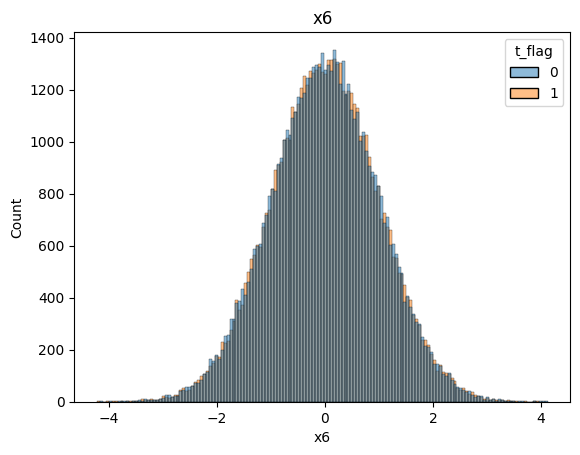

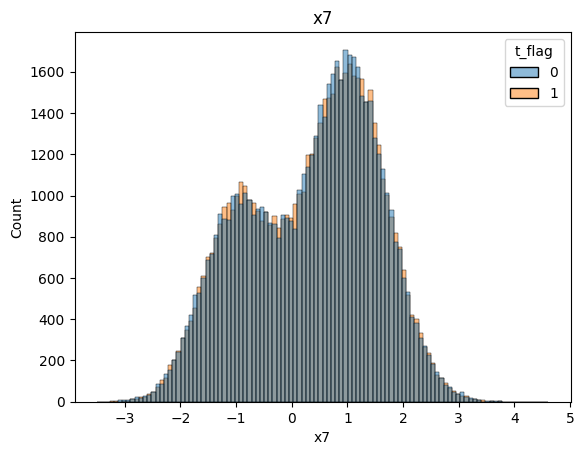

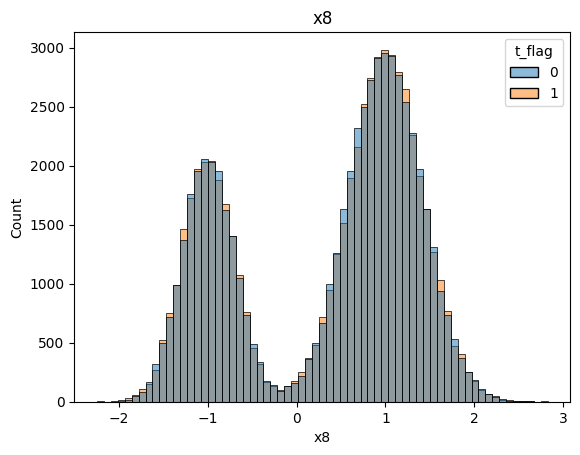

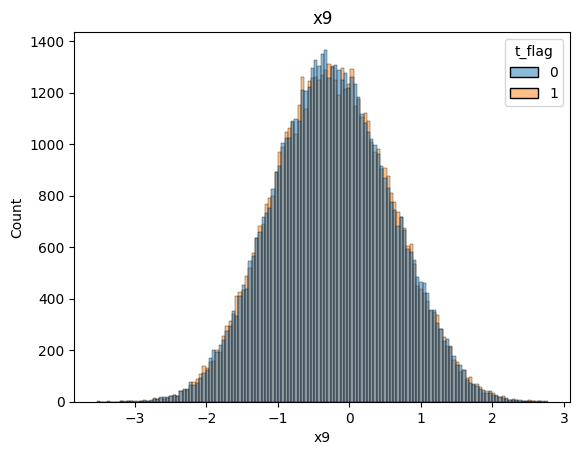

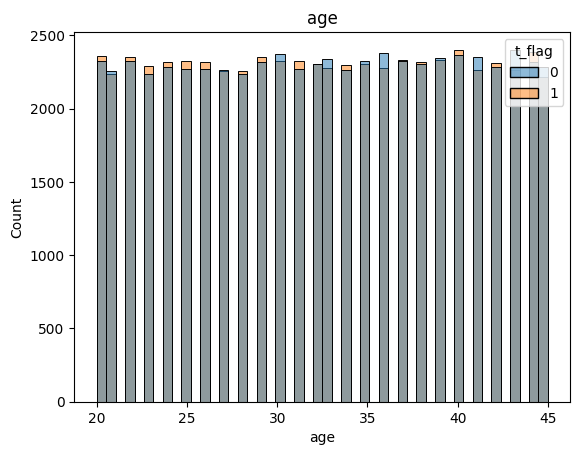

psi для признака x1 равно 0.0004
psi для признака x2 равно 0.0003
psi для признака x3 равно 0.0002
psi для признака x4 равно 0.0001
psi для признака x5 равно 9.2094
psi для признака x6 равно 0.0002
psi для признака x7 равно 0.0004
psi для признака x8 равно 0.0004
psi для признака x9 равно 0.0004
psi для признака age равно 0.0001


C:\Users\admin\AppData\Local\Temp\ipykernel_13128\3280721632.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  input /= np.max(input) / (max - min)


In [197]:
idkfa_df = campaing_EDA('idkfa')

**ВЫВОД**

* индекс psi по призннаку х5 показыввает, что выборки статистически различимы. Использовать этот признак при обучении мы не можем

# <h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

### Вспомогательные функции

*НАПИШЕМ НЕСКОЛЬКО ВСПОМОГАТЕЛЬНЫХ ФУНКЦИЯ ДЛЯ ПРЕДОБРАБОТКИ ДАННЫХ, РАЗБИЕНИЯ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКУ, С УЧЕТОМ 2 ТАРГЕТОВ, И ФУНКЦИЮ ПО РАСЧЕТУ МЕТРИК И ОТРИСОВКЕ ГРАФИКОВ*

In [191]:
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, MinMaxScaler

def preproc_df(df: pd.DataFrame):

    ''' 
    Функция для предобработки датасета перед подачей в модель.
    - Кодирование категориальных столбцов: бинаризация столбца 'age', OHE столбца 'city'
    - Удаление столбцов с датами (по условию работаем не с временными рядами)
    - Скалирование MinMaxScaler
    - разделение на матрицу признаков и вектор ответов
    '''

    df=df.reset_index()
    
    #бинаризуем признак age
    df['age_bins']= KBinsDiscretizer(n_bins=5, encode='ordinal').fit_transform(np.array(df['age']).reshape(-1, 1))
    
    #закодируем признак city OHE
    ohe_df=OneHotEncoder(sparse_output=False).set_output(transform="pandas").fit_transform(np.array(df['city']).reshape(-1, 1))
    df = pd.concat([df, ohe_df], axis=1).drop(['city'], axis=1)

    #удалим лишние столбцы - с датами
    X=df.drop(columns=['index', 'campaing_id', 'delivery_date', 'contract_date', 'target', 'report_dt_x', 'age'])
    y=df['target']

    #масштабируем данные
    X = MinMaxScaler().fit_transform(X, y)

    return df, X, y
    

In [ ]:
def stratified_train_test_split(df):

    ''' 
    Функция для разделения на train и test часть учитывая и таргет и флаг коммуникации
    '''
    campaing_name = str(df['campaing_id'].unique()[0])
    print(f'Кампания {campaing_name}')
    #удалим признаки, которые не можем использовать, согласно EDA
    if campaing_name == 'idkfa':
        df = df.drop(columns=['x5'])
    _, X, y = preproc_df(df)
    
    #в целях корректной стратификации, чтобы учесть и таргет и флаг, создадим список пар флаг-таргет 
    stratification_item=pd.Series(list( zip( list( map( int, X[:, 0] ) ), list( map( int, y ) ) ) ))
    X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=RANDOM_STATE,
                                                    stratify=stratification_item)
    print (f'Размер train части {X_train.shape[0]}, размер test части {X_test.shape[0]}')

    return X_train, X_test, y_train, y_test

In [222]:
def metrics_and_curves (uplift): 
    
    #расчет метрик
    print('Метрики')
    print(f' Uplift@k  {uplift_at_k(y_true=y_test, uplift=uplift, treatment=X_test[:, 0], strategy="by_group", k=0.2) :.5f}')
    print(f' Uplift_auc_score {uplift_auc_score(y_true=y_test, uplift=uplift, treatment=X_test[:, 0]) :.5f}')
    print(f' Qini_auc_score {qini_auc_score(y_true=y_test, uplift=uplift, treatment=X_test[:, 0]) :.5f}')

    #отрисовка Qini curve
    plot_qini_curve(y_true=y_test,
                  uplift=uplift,
                  treatment=X_test[:, 0])
    plt.show()
    
    #отрисовка плотности распределения uplift
    uplift_pd = pd.DataFrame(data = uplift, columns=['uplift'])
    uplift_pd = uplift_pd.sort_values(by='uplift', ascending=False)
    sns.histplot(data = uplift_pd, x=uplift).set_title('uplift')
    plt.show()
  
    print('_'*100)
    print()

## Solomodel

In [198]:
#п.1 Реализован только подход Solomodel без дополнительных библиотек и калибровок

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate


estimator = LogisticRegression(random_state=RANDOM_STATE)

#прикинем качество логистической регрессии на данных
for df in [iddqd_df, iddt_df, idkfa_df]:
    campaing_name = str(df['campaing_id'].unique()[0])
    print(f'Кампания {campaing_name}')
    #удалим признаки, которые не можем использовать, согласно EDA
    if campaing_name == 'idkfa':
        df = df.drop(columns=['x5'])
    _, X, y = preproc_df(df)
    cross_validation = cross_validate(estimator, X, y, cv=5)
    print(cross_validation['test_score'])
    print('_'*100)

Кампания iddqd
[0.85459375 0.85275    0.85121875 0.85084375 0.8525    ]
____________________________________________________________________________________________________
Кампания iddt
[0.95025    0.95329167 0.95366667 0.95270833 0.95370833]
____________________________________________________________________________________________________
Кампания idkfa
[0.95425    0.95316667 0.95245833 0.95183333 0.95129167]
____________________________________________________________________________________________________


In [ ]:
%pip install scikit-uplift

Кампания iddqd
Размер train части 120000, размер test части 40000
Метрики
 Uplift@k  0.67350
 Uplift_auc_score 0.30969
 Qini_auc_score 0.22356


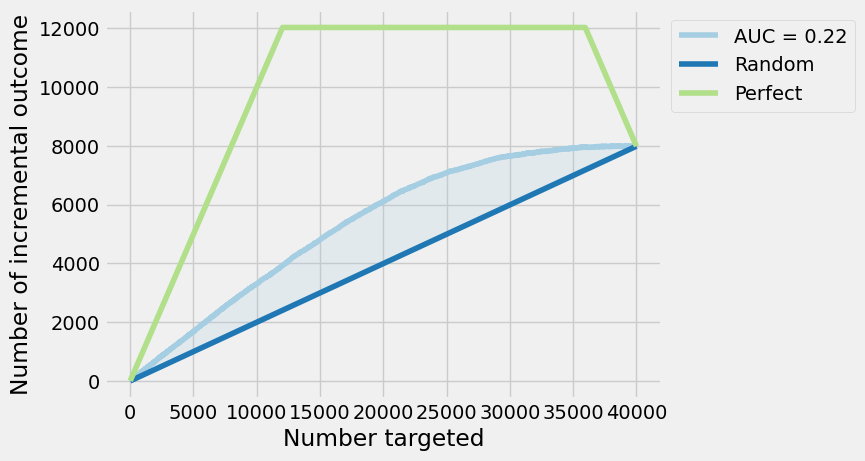

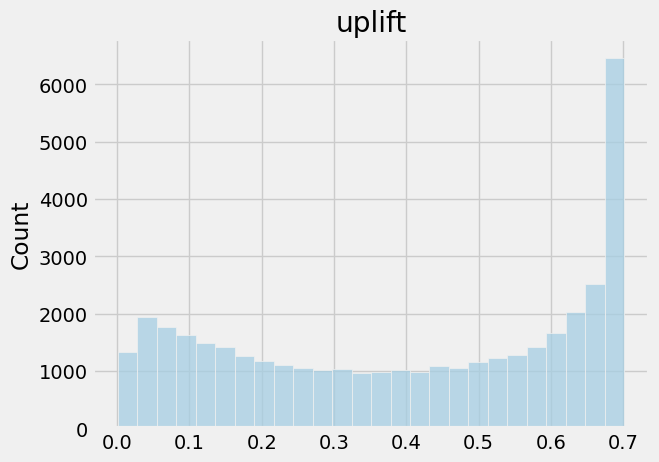

____________________________________________________________________________________________________

Кампания iddt
Размер train части 90000, размер test части 30000
Метрики
 Uplift@k  0.82633
 Uplift_auc_score 0.29338
 Qini_auc_score 0.19864


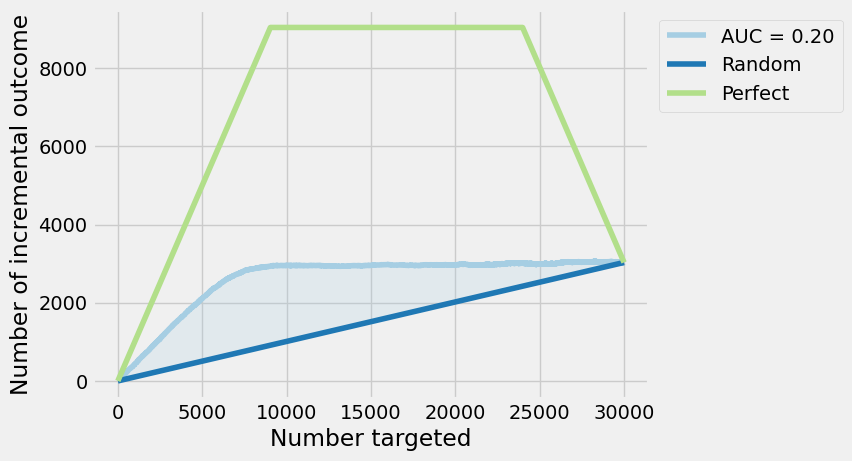

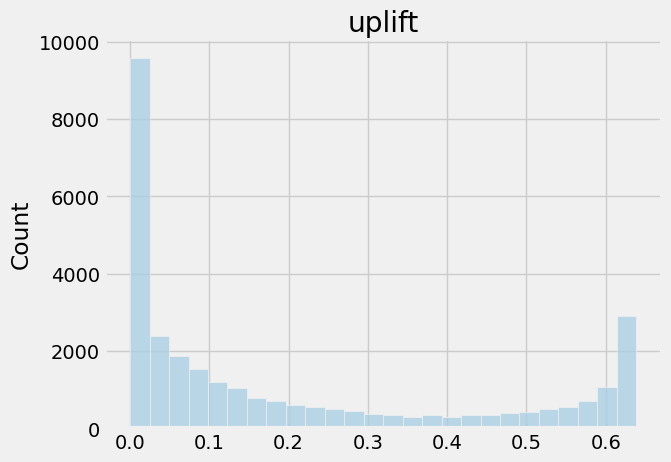

____________________________________________________________________________________________________

Кампания idkfa
Размер train части 90000, размер test части 30000
Метрики
 Uplift@k  0.82867
 Uplift_auc_score 0.28989
 Qini_auc_score 0.19876


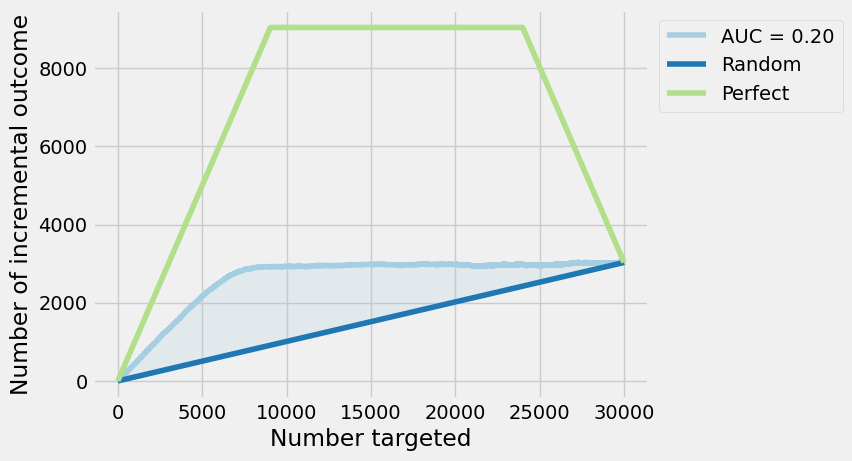

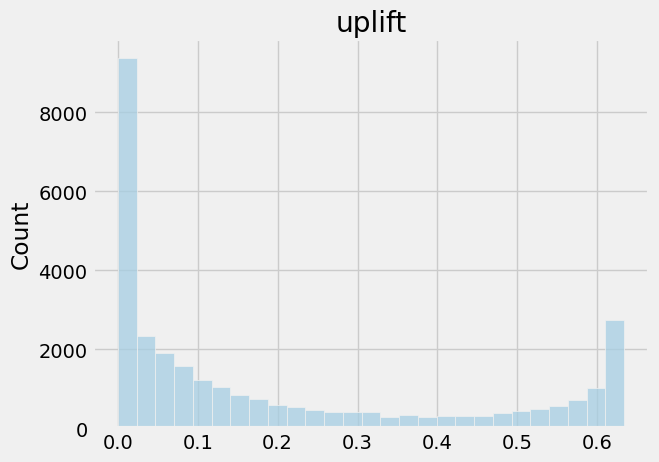

____________________________________________________________________________________________________



In [225]:
#качество норм, делим данные на train и test и обучаем логрег на таргет, а затем подставляем в тест флаг коммуникации 1 и 0

from sklearn.model_selection import train_test_split
import sklift
from sklift.metrics import (uplift_at_k,
                            uplift_auc_score,
                            qini_auc_score,
                            make_uplift_scorer)
from sklearn.utils._optional_dependencies import (check_matplotlib_support,
check_pandas_support)
import sklearn.utils 
sklearn.utils.check_matplotlib_support=check_matplotlib_support
from sklift.viz import plot_qini_curve


for df in [iddqd_df, iddt_df, idkfa_df]:
    
    X_train, X_test, y_train, y_test = stratified_train_test_split(df)
    
    #обучаем логрег
    estimator.fit(X_train, y_train)
    
    #ставим всем клиентам из теста флаг коммуникации =1 и скорим их моделью
    X_test_1 = X_test.copy()
    X_test_1[:,0]=1
    y_pred_1 = estimator.predict_proba(X_test_1)[:,1]

    #ставим всем клиентам из теста флаг коммуникации =0 и скорим их моделью
    X_test_0 = X_test.copy()
    X_test_0[:,0]=0
    y_pred_0 = estimator.predict_proba(X_test_0)[:,1]

    #считаем uplift
    uplift_logreg = y_pred_1 - y_pred_0
    #метрики и графики
    metrics_and_curves (uplift_logreg)

*ВЫВОДЫ:*

* подход Solomodel с использованием логистической регрессии позволил четко выделить клиентов с высоким уровнем uplift, метрики качества Qini получились на уровне 0.2

* ни одному из клиентов Solomodel не дала отрицательный uplift

## Twomodels

Кампания iddqd
Размер train части 120000, размер test части 40000
Метрики
 Uplift@k  0.99325
 Uplift_auc_score 0.53576
 Qini_auc_score 0.38003


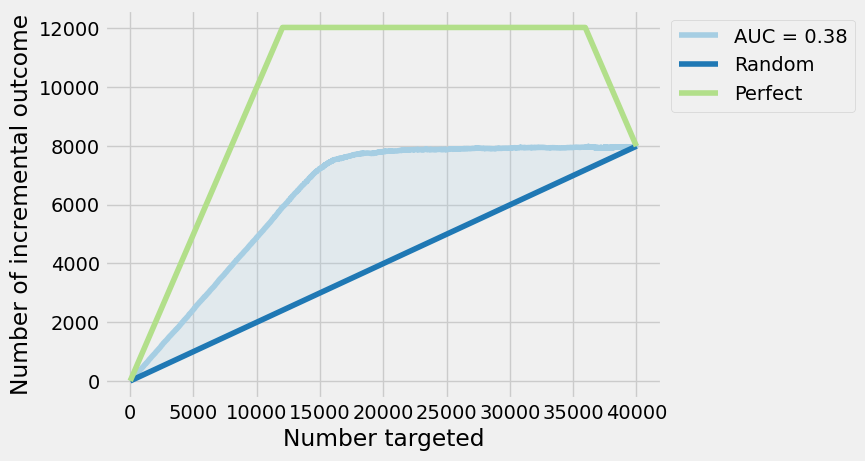

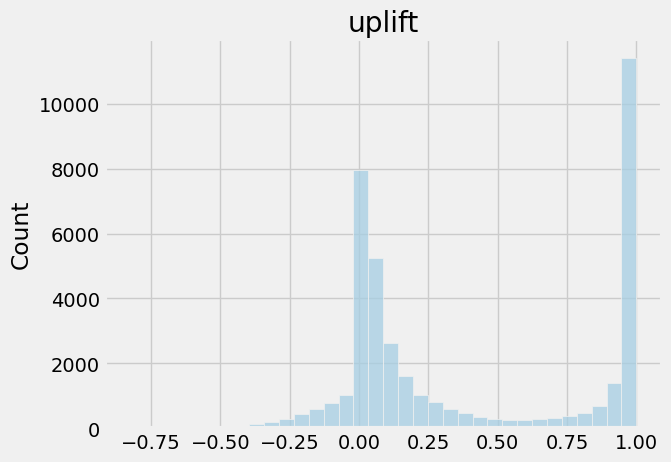

____________________________________________________________________________________________________

Кампания iddt
Размер train части 90000, размер test части 30000
Метрики
 Uplift@k  0.96500
 Uplift_auc_score 0.30800
 Qini_auc_score 0.20748


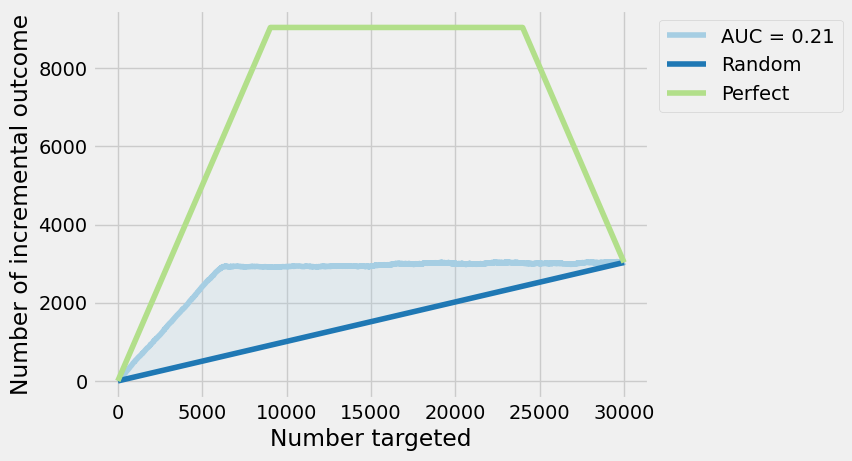

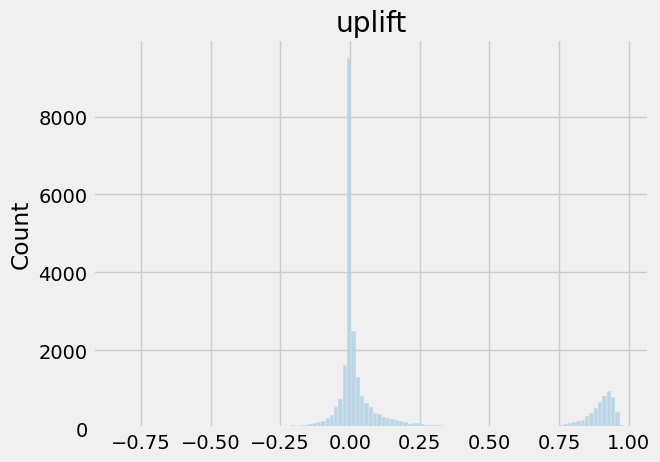

____________________________________________________________________________________________________

Кампания idkfa
Размер train части 90000, размер test части 30000
Метрики
 Uplift@k  0.96200
 Uplift_auc_score 0.30923
 Qini_auc_score 0.21047


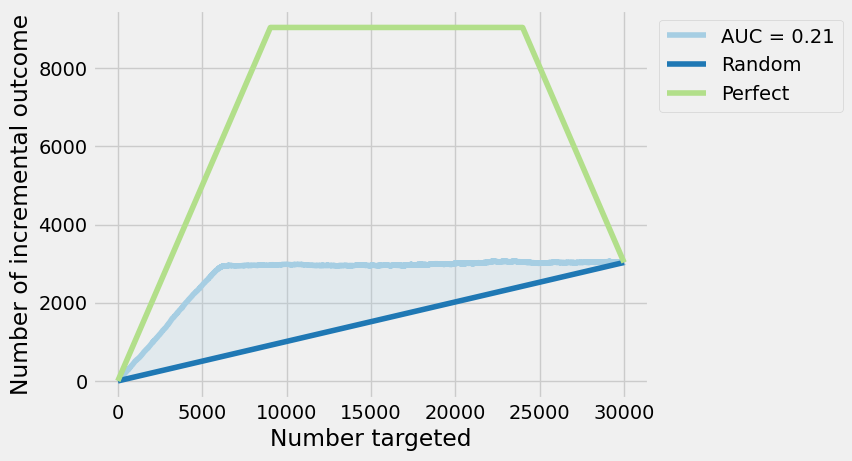

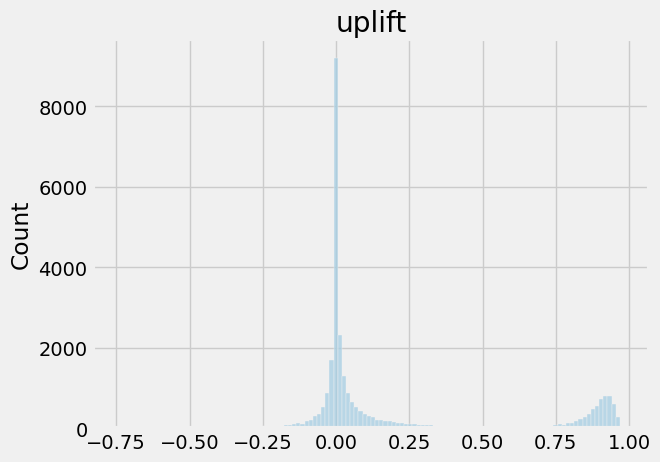

____________________________________________________________________________________________________



In [224]:
# п.2 Реализован Solomodel или Twomodel через Sklift или CausalML

from sklift.models import TwoModels

model_1 = LogisticRegression(random_state=RANDOM_STATE+1)
model_2 = LogisticRegression(random_state=RANDOM_STATE+2)

#независимые модели
twomodels = TwoModels(estimator_trmnt=model_1,
                   estimator_ctrl=model_2,
                   method='vanilla')

for df in [iddqd_df, iddt_df, idkfa_df]:

    X_train, X_test, y_train, y_test = stratified_train_test_split(df)
    
    #обучаем 
    twomodels.fit(X_train[:, 1:],
           y_train,
           treatment=X_train[:, 0])

    uplift_twomodels = twomodels.predict(X_test[:, 1:])

    metrics_and_curves (uplift_twomodels)

Кампания iddqd
Размер train части 120000, размер test части 40000
Метрики
 Uplift@k  0.99250
 Uplift_auc_score 0.54418
 Qini_auc_score 0.38504


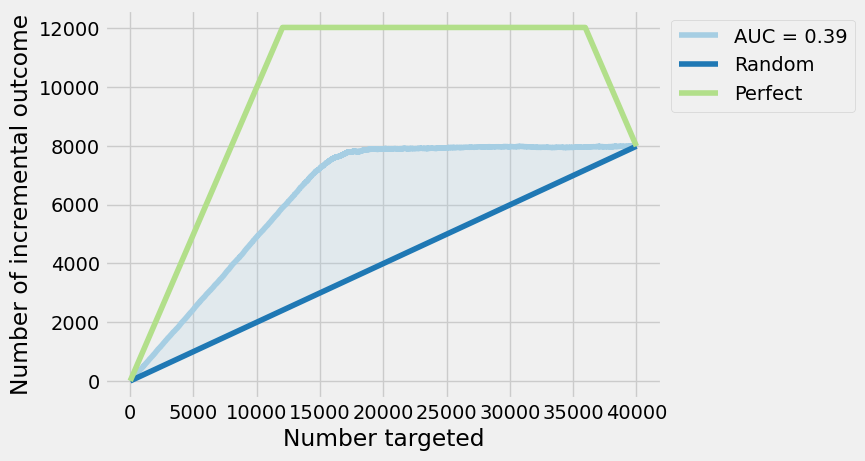

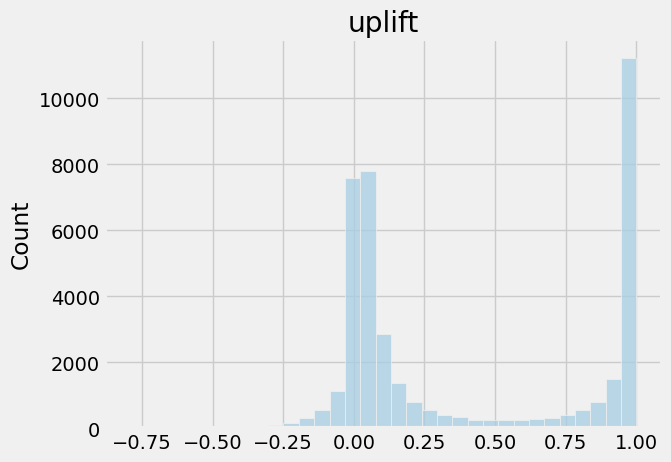

____________________________________________________________________________________________________

Кампания iddt
Размер train части 90000, размер test части 30000
Метрики
 Uplift@k  0.97000
 Uplift_auc_score 0.31191
 Qini_auc_score 0.21097


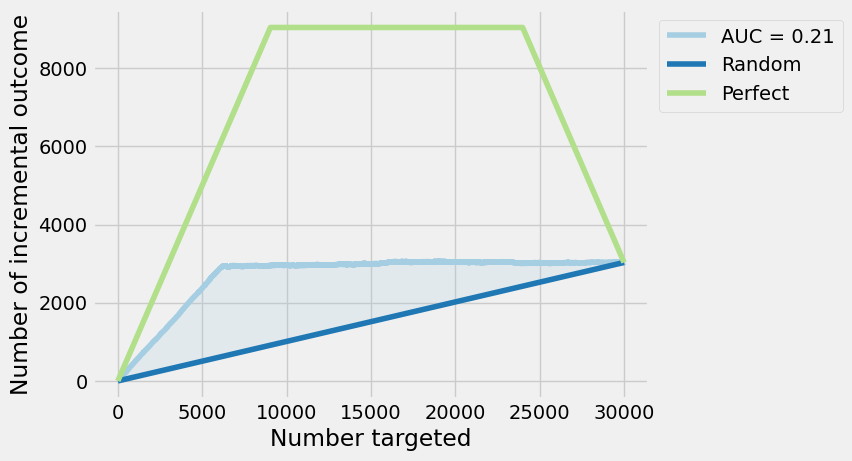

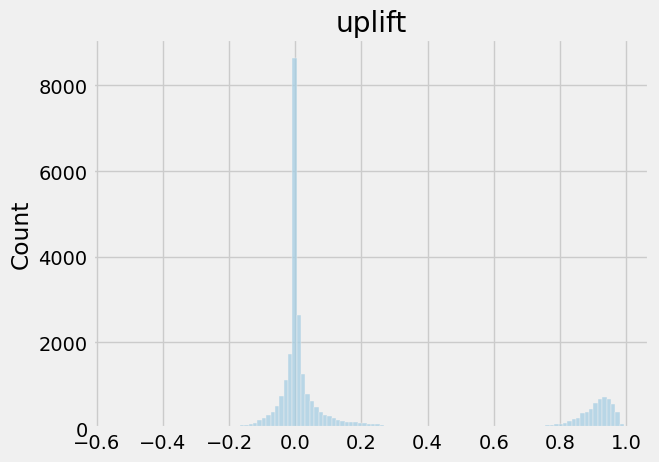

____________________________________________________________________________________________________

Кампания idkfa
Размер train части 90000, размер test части 30000
Метрики
 Uplift@k  0.96667
 Uplift_auc_score 0.31164
 Qini_auc_score 0.21248


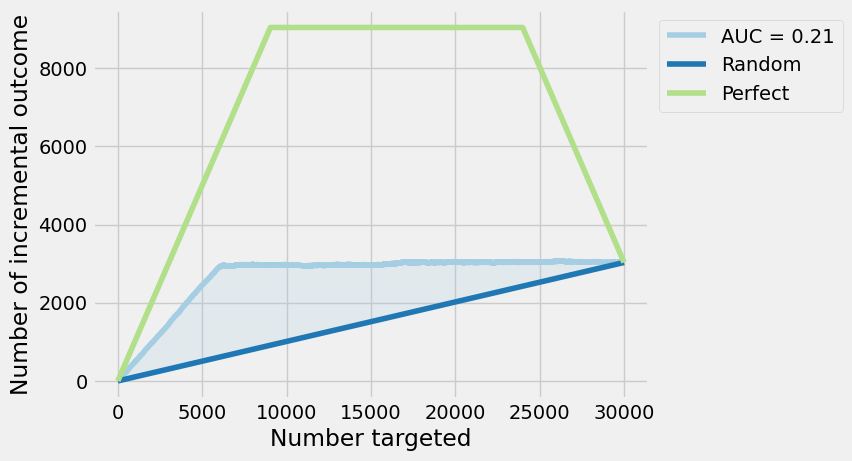

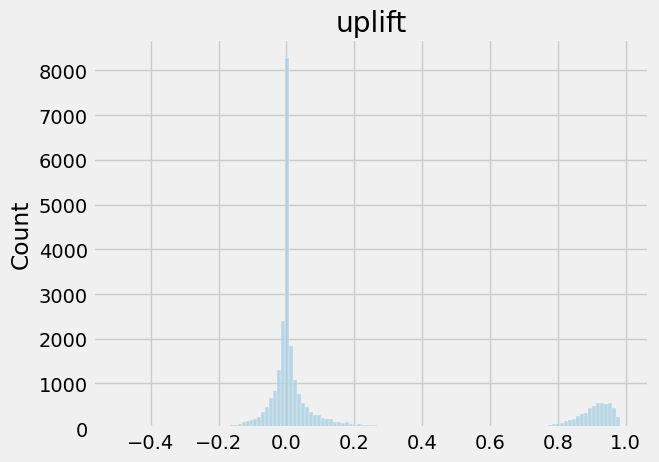

____________________________________________________________________________________________________



In [223]:
#зависимые модели
twomodels = TwoModels(estimator_trmnt=model_1,
                   estimator_ctrl=model_2,
                   method='ddr_control')

for df in [iddqd_df, iddt_df, idkfa_df]:
    X_train, X_test, y_train, y_test = stratified_train_test_split(df)
    
    #обучаем 
    twomodels.fit(X_train[:, 1:],
           y_train,
           treatment=X_train[:, 0])

    uplift_twomodels = twomodels.predict(X_test[:, 1:])

    metrics_and_curves (uplift_twomodels)

*ВЫВОДЫ:*

* подход Twomodels показал более высокое качество по Qini Score
* плотность распределения uplift в таком подходе больше стремиться к 0 и правому краю распределения, появились отрицательные значения uplift

## Калибровка Metalearner'ов

Кампания iddqd
Размер train части 120000, размер test части 40000
Метрики
 Uplift@k  0.99100
 Uplift_auc_score 0.55028
 Qini_auc_score 0.38954


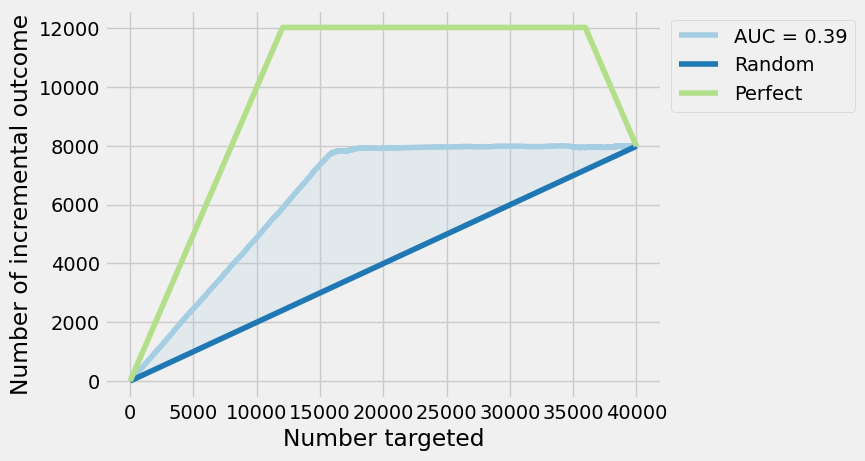

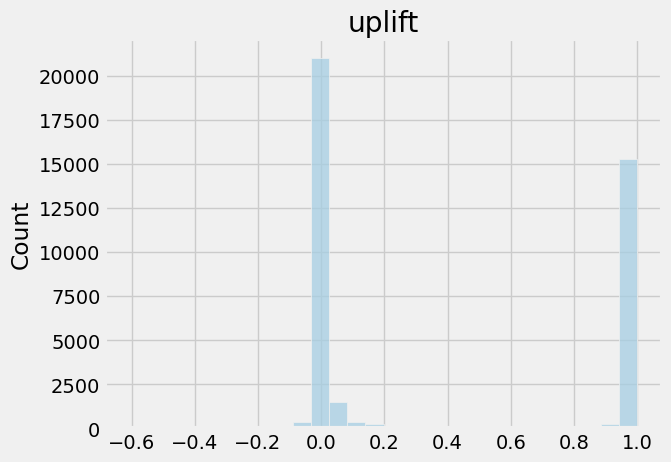

____________________________________________________________________________________________________

Кампания iddt
Размер train части 90000, размер test части 30000
Метрики
 Uplift@k  0.97500
 Uplift_auc_score 0.30876
 Qini_auc_score 0.20915


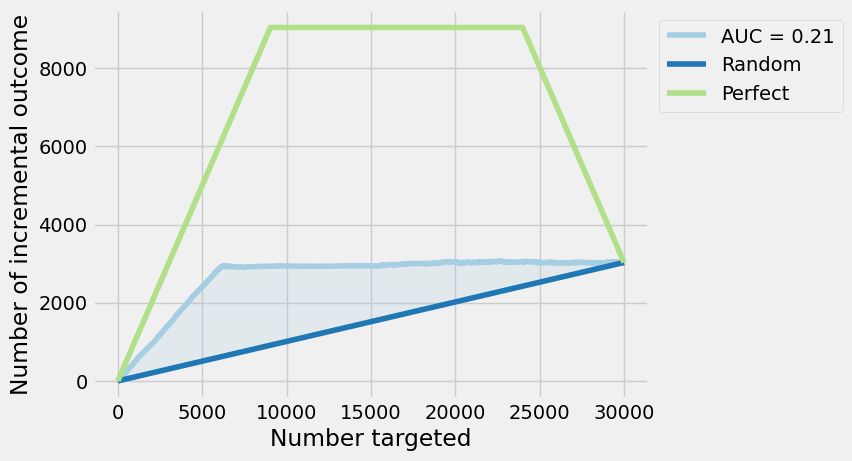

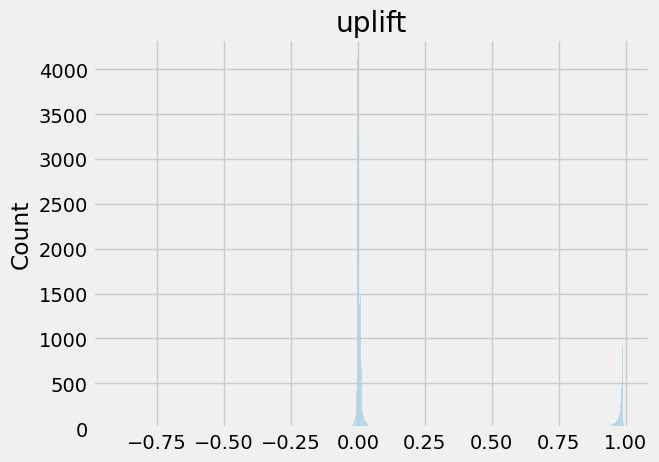

____________________________________________________________________________________________________

Кампания idkfa
Размер train части 90000, размер test части 30000
Метрики
 Uplift@k  0.97167
 Uplift_auc_score 0.30521
 Qini_auc_score 0.21186


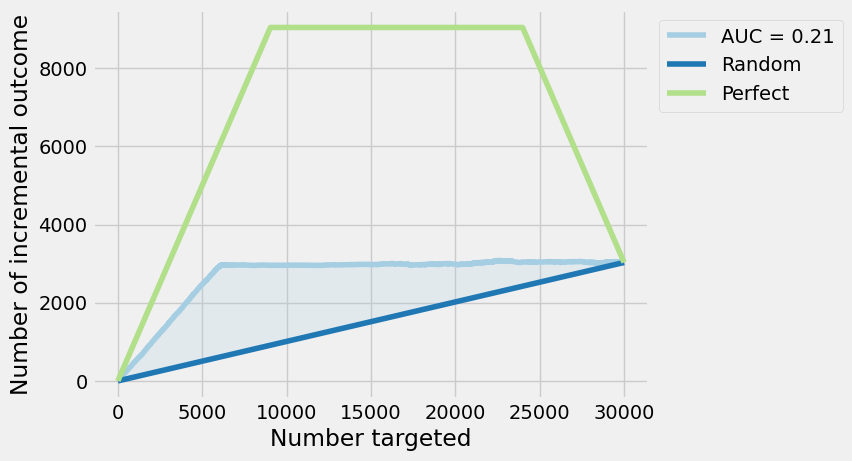

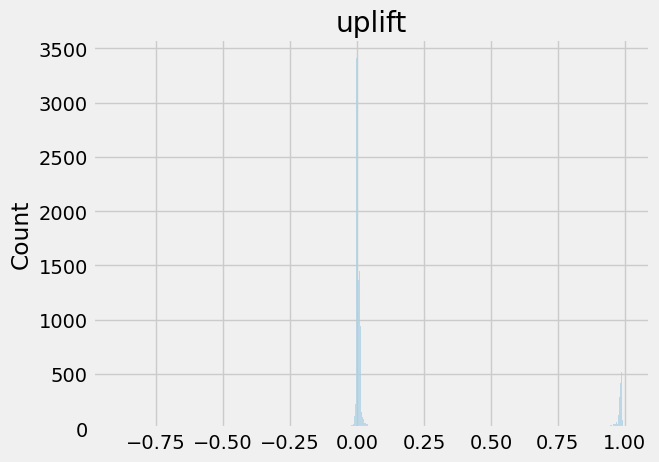

____________________________________________________________________________________________________



In [226]:
#п.3 Учтена калибровка Metalearner'ах

from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV

skf = StratifiedKFold(n_splits=5,
                      random_state=RANDOM_STATE,
                      shuffle=True)

#т.к. подход Twomodels показал себя лучше, будем использовать его
cb_1 = CatBoostClassifier(verbose=0, random_seed=RANDOM_STATE, thread_count=-1)
cb_2 = CatBoostClassifier(verbose=0, random_seed=RANDOM_STATE+1, thread_count=-1)

calib_model_1 = CalibratedClassifierCV(estimator=cb_1, method='isotonic', cv=skf)
calib_model_2 = CalibratedClassifierCV(estimator=cb_2, method='isotonic', cv=skf)

twomodels_cb = TwoModels(estimator_trmnt=calib_model_1,
                        estimator_ctrl=calib_model_2)

for df in [iddqd_df, iddt_df, idkfa_df]:

    X_train, X_test, y_train, y_test = stratified_train_test_split(df)

    twomodels_cb.fit(X_train[:, 1:],
                y_train,
                treatment=X_train[:, 0])

    uplift_twomodels_calibrated_catboost = twomodels_cb.predict(X_test[:, 1:])

    metrics_and_curves(uplift_twomodels_calibrated_catboost)

*ВЫВОДЫ:*

* обученный на кросс-валидации катбуст с калибровкой вероятностей дает качество, аналогичное Twomodels логрегрессиям

* при этом распределене uplift еще больше стремится к 0 и правому краю 

## ClassTransformation

Кампания iddqd
Размер train части 120000, размер test части 40000
Метрики
 Uplift@k  0.99225
 Uplift_auc_score 0.54478
 Qini_auc_score 0.38606


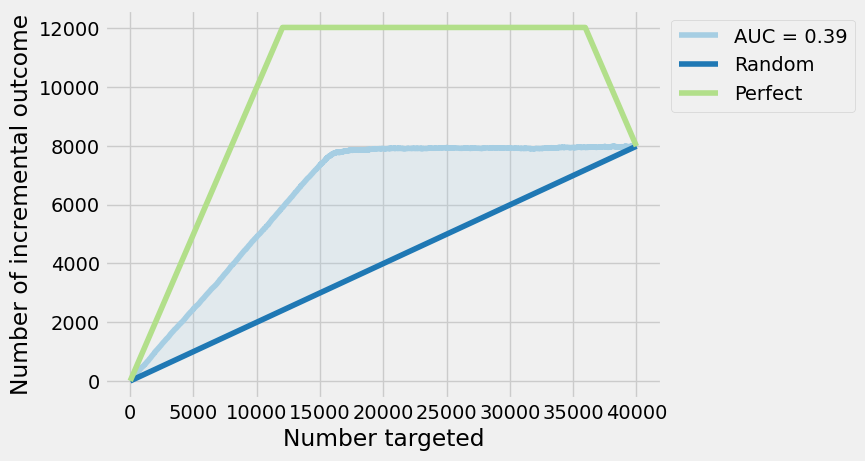

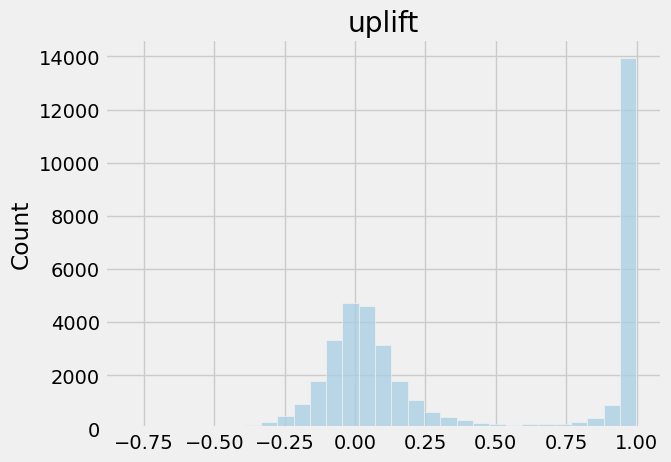

____________________________________________________________________________________________________

Кампания iddt
Размер train части 90000, размер test части 30000
Метрики
 Uplift@k  0.96833
 Uplift_auc_score 0.31708
 Qini_auc_score 0.21615


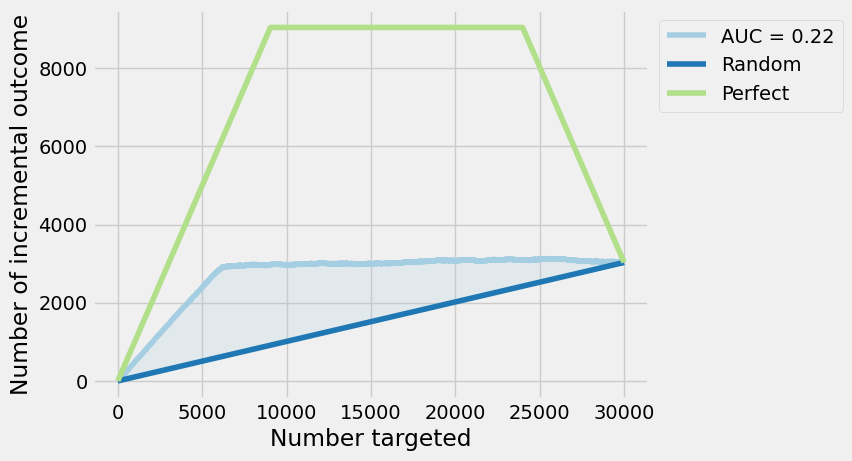

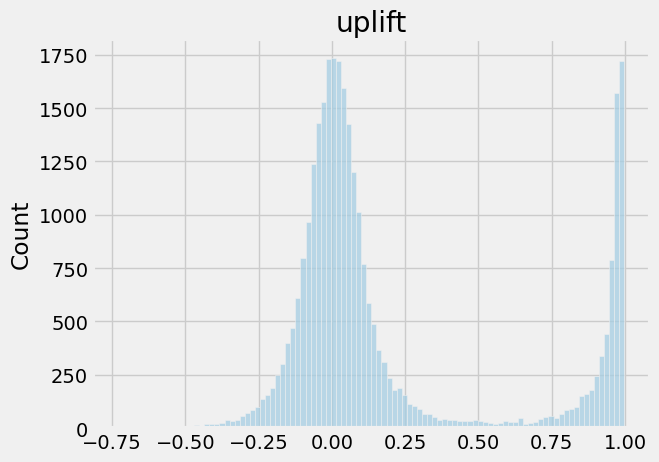

____________________________________________________________________________________________________

Кампания idkfa
Размер train части 90000, размер test части 30000
Метрики
 Uplift@k  0.96100
 Uplift_auc_score 0.46223
 Qini_auc_score 0.31653


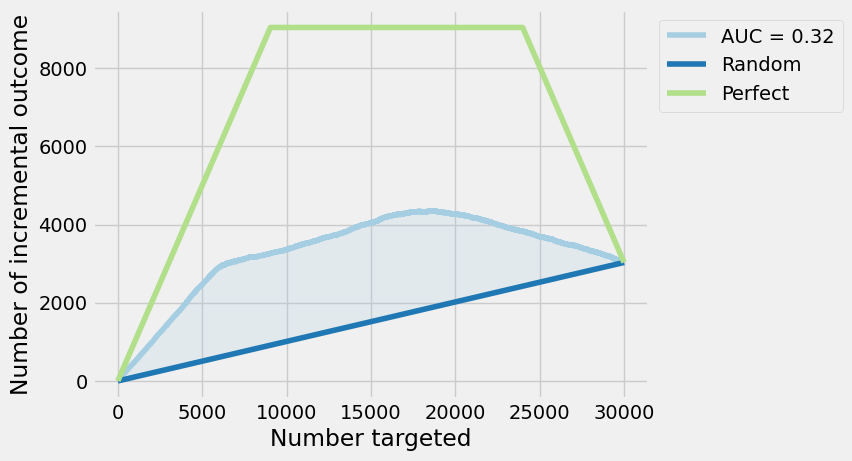

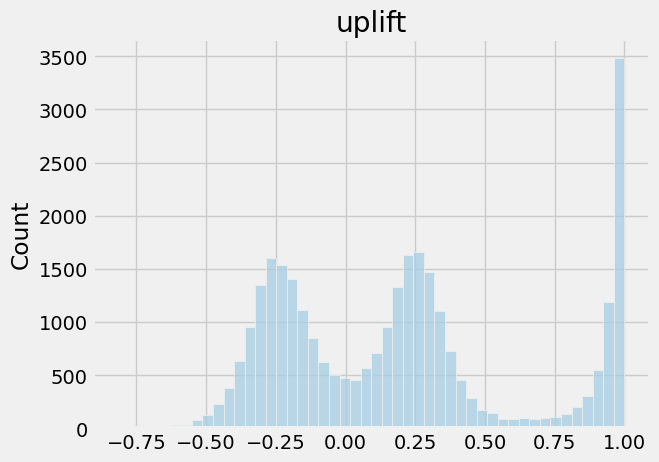

____________________________________________________________________________________________________



In [231]:
#п.4 Корректно реализован ClassTransformation

from sklift.models import ClassTransformation

catboost = CatBoostClassifier(verbose=0, random_seed=RANDOM_STATE, thread_count=-1)
class_transformer = ClassTransformation(catboost)

for df in [iddqd_df, iddt_df, idkfa_df]:

    X_train, X_test, y_train, y_test = stratified_train_test_split(df)

    class_transformer.fit(X_train[:, 1:],
                y_train,
                treatment=X_train[:, 0])

    uplift_class_transformer = class_transformer.predict(X_test[:, 1:])

    metrics_and_curves(uplift_class_transformer)

*ВЫВОД:*

* по некоторым кампаниям значения qini score получились выше, чем в предыдущих подходах (SoloModel, TwoModels и с калибровкой вероятностей)

* значения uplift в меньшей степени смещены к 0 или 1

# UpliftRandomForest

In [ ]:
# п.5 Реализован UpliftRandomForest



## Тюнинг Optuna

In [230]:
#п.7 Реализован тюнинг ( Optuna )

import optuna
from sklift.metrics import make_uplift_scorer

def objective_tm_lr(trial):

    param = {
            'C_1':trial.suggest_float("C_1", 0, 3),
            'C_2':trial.suggest_float("C_2", 0, 3),
            'method':trial.suggest_categorical("method", ['vanilla', 'ddr_control', 'ddr_treatment'])
    }
    #если бы у нас была не логрегрессия, то мы бы еще обернули в CalibratedClassifier
    model_1 = LogisticRegression(random_state=RANDOM_STATE+1, C=param['C_1'])
    model_2 = LogisticRegression(random_state=RANDOM_STATE+2, C=param['C_2'])

    tm = TwoModels(estimator_trmnt=model_1,
                       estimator_ctrl=model_2,
                       method=param['method'])
    
    X_train, X_test, y_train, y_test = stratified_train_test_split(iddqd_df)
    
    qini_scorer = make_uplift_scorer("qini_auc_score", pd.Series(X_train[:, 0]))

    cross_val = cross_validate(tm,
                               X=X_train[:, 1:],
                               y=y_train,
                               params={'treatment': X_train[:, 0]},
                               scoring=qini_scorer,
                               cv=skf,
                               n_jobs=-1,
                               return_train_score=True)

    #мы ищем не просто самую лучшую модель, а самую стабильную
    return cross_val['test_score'].mean() - cross_val['test_score'].std()

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_tm = optuna.create_study(direction="maximize")
study_tm.optimize(objective_tm_lr,
                  n_trials=500,
                  show_progress_bar=True)

  0%|          | 0/500 [00:00<?, ?it/s]

Кампания iddqd
Размер train части 120000, размер test части 40000


  0%|          | 1/500 [00:01<12:13,  1.47s/it]

[W 2025-03-05 15:08:07,714] Trial 0 failed with parameters: {'C_1': 1.6748540077822849, 'C_2': 2.1217019705105207, 'method': 'vanilla'} because of the following error: The value nan is not acceptable.
[W 2025-03-05 15:08:07,716] Trial 0 failed with value nan.
Кампания iddqd
Размер train части 120000, размер test части 40000


  0%|          | 2/500 [00:02<10:44,  1.29s/it]

...

[W 2025-03-05 15:12:48,002] Trial 497 failed with parameters: {'C_1': 1.6477378871412593, 'C_2': 2.9490871654526774, 'method': 'ddr_treatment'} because of the following error: The value nan is not acceptable.
[W 2025-03-05 15:12:48,004] Trial 497 failed with value nan.
Кампания iddqd
Размер train части 120000, размер test части 40000


100%|█████████▉| 499/500 [04:42<00:00,  1.84it/s]

[W 2025-03-05 15:12:48,529] Trial 498 failed with parameters: {'C_1': 0.5163803853463271, 'C_2': 1.6043859780352898, 'method': 'ddr_treatment'} because of the following error: The value nan is not acceptable.
[W 2025-03-05 15:12:48,531] Trial 498 failed with value nan.
Кампания iddqd
Размер train части 120000, размер test части 40000


100%|██████████| 500/500 [04:42<00:00,  1.77it/s]

[W 2025-03-05 15:12:49,101] Trial 499 failed with parameters: {'C_1': 0.056291275565505616, 'C_2': 0.3019960138022575, 'method': 'ddr_control'} because of the following error: The value nan is not acceptable.
[W 2025-03-05 15:12:49,103] Trial 499 failed with value nan.


In [ ]:
#Реализован Solomodel или Twomodel через Sklift или CausalML

!pip uninstall -y causalml scikit-learn numpy scipy
!pip install scikit-learn==1.2.2 numpy==1.23.5 scipy causalml

In [201]:
from causalml.inference.tree import UpliftRandomForestClassifier

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to import duecredit due to No module named 'duecredit'


In [206]:
from sklearn.utils._optional_dependencies import (check_matplotlib_support,
check_pandas_support)
import sklearn.utils 
sklearn.utils.check_matplotlib_support=check_matplotlib_support
from sklift.viz import plot_qini_curve

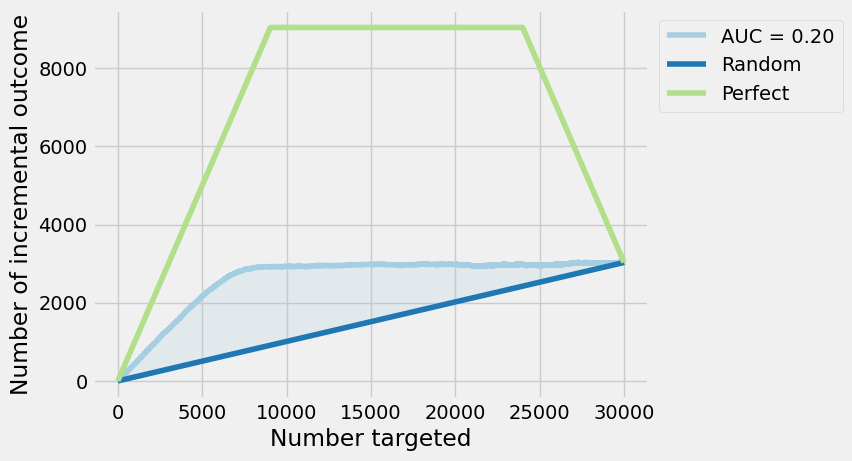

In [207]:
plot_qini_curve(y_true=y_test,
                  uplift=uplift_logreg,
                  treatment=X_test[:, 0])
plt.show()

# <h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [ ]:
# ваш код здесь

### ваши выводы здесь